## 0. Dataset collection for BTC-USD

In [2]:
import pandas as pd
import yfinance as yf
import datetime as dt
import requests
import time

def fetch_integrated_dataset(days=730):
    end_date = dt.date.today()
    print(end_date)
    start_date = end_date - dt.timedelta(days=days)

    # --- 1. 获取市场价格数据 (Yahoo Finance) ---
    symbols = {
        "LTC": "LTC-USD", "XRP": "XRP-USD", "ETH": "ETH-USD", "DOGE": "DOGE-USD",
        "Gold": "GC=F", "Silver": "SI=F", "Oil": "CL=F",
        "SP500": "^GSPC", "NASDAQ": "^IXIC", "DXY": "DX-Y.NYB",
        "Treasury_10Y": "^TNX", "EUR": "EURUSD=X", "JPY": "JPYUSD=X"
    }

    print(f"[INFO] 正在获取价格数据...")
    try:
        btc = yf.download("BTC-USD", start=start_date, end=end_date)
        if isinstance(btc.columns, pd.MultiIndex): btc.columns = btc.columns.get_level_values(0)

        main_df = btc[['Open', 'Close', 'High', 'Low', 'Volume']].copy()
        main_df.columns = ['BTC_Open', 'BTC_Close', 'BTC_High', 'BTC_Low', 'BTC_Volume']
        # 确保索引是标准的 DatetimeIndex
        main_df.index = pd.to_datetime(main_df.index)
    except Exception as e:
        print(f"[ERROR] BTC 数据获取失败: {e}")
        return None
    # 获取其他资产
    for name, ticker in symbols.items():
        temp = yf.download(ticker, start=start_date, end=end_date, progress=False)
        if not temp.empty:
            if isinstance(temp.columns, pd.MultiIndex): temp.columns = temp.columns.get_level_values(0)
            col = "Adj Close" if "Adj Close" in temp.columns else "Close"
            main_df[f"{name}_close"] = temp[col]

    # --- 2. 获取链上技术特征 (b) ---
    onchain_metrics = {
        "Active_addr_cnt": "n-unique-addresses",
        "Xfer_cnt": "n-transactions",
        "Mean_hash_rate": "hash-rate",
        "Difficulty": "difficulty",
        "Total_fees_USD": "transaction-fees-usd",
        "Mean_block_size": "avg-block-size"
    }

    print("[INFO] 正在获取链上数据...")
    for col_name, api_slug in onchain_metrics.items():
        try:
            url = f"https://api.blockchain.info/charts/{api_slug}?timespan=all&format=json&cors=true"
            resp = requests.get(url, timeout=15)
            if resp.status_code == 200:
                data = resp.json()
                df_temp = pd.DataFrame(data['values'])
                df_temp['x'] = pd.to_datetime(df_temp['x'], unit='s')
                df_temp = df_temp.set_index('x')['y'].rename(col_name)
                # 关键修复：确保链上数据索引也是 DatetimeIndex
                df_temp.index = pd.to_datetime(df_temp.index)
                # 重采样并填充，确保每一天都有值
                df_temp = df_temp.resample('D').mean().ffill()
                # 合并
                main_df = main_df.join(df_temp, how='left')
                print(f"      - {col_name}: 成功")
            time.sleep(0.5)
        except Exception as e:
            print(f"      [WARN] {col_name} 失败: {e}")

    # --- 3. 生成衍生时间特征 (h) ---
    print("[INFO] 正在生成日期哑变量...")
    # 确保 main_df.index 拥有 weekday 属性
    main_df.index = pd.to_datetime(main_df.index)

    days_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for i, day in enumerate(days_names):
        # 修正：使用 .index.weekday 获取星期索引 (0=Monday)
        main_df[day] = (main_df.index.weekday == i).astype(int)

    # --- 4. 数据后处理 ---
    main_df = main_df.ffill().bfill()
    return main_df

dataset = fetch_integrated_dataset(days=1460)
if dataset is not None:
    out_file = "Macro_BTC_Dataset.xlsx"
    dataset.to_excel(out_file)
    print("-" * 30)
    print(f"任务完成！")
    print(f"文件保存至: {out_file}")
    print(f"最终特征总数: {dataset.shape[1]}")
    print(f"日期范围: {dataset.index.min()} 至 {dataset.index.max()}")
    print("-" * 30)

[*********************100%***********************]  1 of 1 completed

2026-04-14
[INFO] 正在获取价格数据...


[INFO] 正在获取链上数据...
      - Active_addr_cnt: 成功
      - Xfer_cnt: 成功
      - Mean_hash_rate: 成功
      - Difficulty: 成功
      - Total_fees_USD: 成功
      - Mean_block_size: 成功
[INFO] 正在生成日期哑变量...
------------------------------
任务完成！
文件保存至: Macro_BTC_Dataset.xlsx
最终特征总数: 31
日期范围: 2022-04-15 00:00:00 至 2026-04-13 00:00:00
------------------------------


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import minimize

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.holtwinters import ExponentialSmoothing

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

## Shared helper functions
These keep the notebook style consistent with the earlier `tsa-II.ipynb` notebook.

In [3]:

def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal,
                                  seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def forecast_df(fit, steps, n_obs):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    idx = np.arange(n_obs+1, n_obs+steps+1)
    return pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci[:,0],
        "upper_95": ci[:,1]
    }, index=idx)

def forecast_plot(y, fc_df, title="Forecast with 95% PI"):
    y = np.asarray(y)
    n = len(y)
    t = np.arange(1, n+1)
    t_fc = fc_df.index.values
    plt.figure(figsize=(10,5))
    plt.plot(t, y, label="observed", linewidth=1.5)
    plt.plot(t_fc, fc_df["forecast"].values, label="forecast", linewidth=2)
    plt.fill_between(t_fc, fc_df["lower_95"].values, fc_df["upper_95"].values, alpha=0.2, label="95% PI")
    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()


## Extra utilities for unit root tests and heteroskedasticity

In [19]:

def unit_root_summary(y, name="series"):
    rows = []
    for reg, label in [("c", "constant"), ("ct", "constant + trend")]:
        try:
            adf_res = adfuller(y, regression=reg, autolag="AIC")
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": adf_res[0],
                "pvalue": adf_res[1],
                "usedlag": adf_res[2]
            })
        except Exception as e:
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
        try:
            kpss_res = kpss(y, regression=reg, nlags="auto")
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": kpss_res[0],
                "pvalue": kpss_res[1],
                "usedlag": kpss_res[2]
            })
        except Exception:
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
    return pd.DataFrame(rows)

def arch_lm_table(y, nlags=4):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, nlags=nlags)
    return pd.DataFrame({
        "LM stat": [lm_stat],
        "LM p-value": [lm_pvalue],
        "F stat": [f_stat],
        "F p-value": [f_pvalue],
        "lags": [nlags]
    })

def plot_hist_density_qq(y, title_prefix="Series"):
    yy = np.asarray(y)
    mu, sig = yy.mean(), yy.std(ddof=0)
    x = np.linspace(mu - 4*sig, mu + 4*sig, 400)

    plt.figure(figsize=(10,5))
    plt.hist(yy, bins=30, density=True, alpha=0.5, label="Histogram")
    kde = stats.gaussian_kde(yy)
    plt.plot(x, kde(x), linewidth=2, label="Kernel density")
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sig), linewidth=2, label="Normal density")
    plt.title(f"{title_prefix}: histogram, kernel density, and normal density")
    plt.tight_layout()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    stats.probplot(yy, dist="norm", plot=plt)
    plt.title(f"{title_prefix}: Normal Q-Q plot")
    plt.tight_layout()
    plt.show()

def get_param(fit, *candidates, default=np.nan):
    names = list(getattr(fit, "param_names", []))
    params = np.asarray(fit.params)
    for c in candidates:
        if c in names:
            return float(params[names.index(c)])
    return default

def fit_arch1(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea = np.exp(u[1])
        alpha = ea / (1 + ea)
        return omega, alpha
    def nll(u):
        omega, alpha = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2
        return 0.5 * np.sum(np.log(h) + y**2 / h)

    res = minimize(nll, [np.log(var0*0.1), np.log(0.1/0.9)], method="L-BFGS-B")
    omega, alpha = unpack(res.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2
    ll = -nll(res.x)
    return {
        "omega": omega, "alpha": alpha, "loglik": ll, "aic": 2*2 - 2*ll,
        "bic": np.log(n)*2 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": res.success
    }

def fit_garch11(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea, eb = np.exp(u[1]), np.exp(u[2])
        s = 1 + ea + eb
        alpha = ea / s
        beta = eb / s
        return omega, alpha, beta
    def nll(u):
        omega, alpha, beta = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    starts = [
        [np.log(var0*0.01), np.log(0.07/0.03), np.log(0.90/0.03)],
        [np.log(var0*0.10), np.log(0.05/0.05), np.log(0.90/0.05)],
        [np.log(var0*0.01), np.log(0.10/0.10), np.log(0.80/0.10)],
    ]
    best = None
    for s in starts:
        r = minimize(nll, s, method="L-BFGS-B")
        if best is None or r.fun < best.fun:
            best = r
    omega, alpha, beta = unpack(best.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
    ll = -nll(best.x)
    return {
        "omega": omega, "alpha": alpha, "beta": beta, "loglik": ll, "aic": 2*3 - 2*ll,
        "bic": np.log(n)*3 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": best.success
    }

def garch_forecast_path(fit_dict, y, steps=10):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    omega = fit_dict["omega"]
    alpha = fit_dict.get("alpha", 0.0)
    beta = fit_dict.get("beta", 0.0)
    h_last = fit_dict["h"][-1]
    y_last = y[-1]
    out = np.empty(steps)
    out[0] = omega + alpha * y_last**2 + beta * h_last
    for k in range(1, steps):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out


Number of monthly observations: 1460
First 10 observations: [40553.4648 40424.4844 39716.9531 40826.2148 41502.75   41374.3789
 40527.3633 39740.3203 39486.7305 39469.293 ]
Last 10 observations: [67290.5156 68981.8984 68859.8281 71940.7031 71123.3594 71767.8281
 72979.0469 73054.2734 70753.4062 74484.6406]


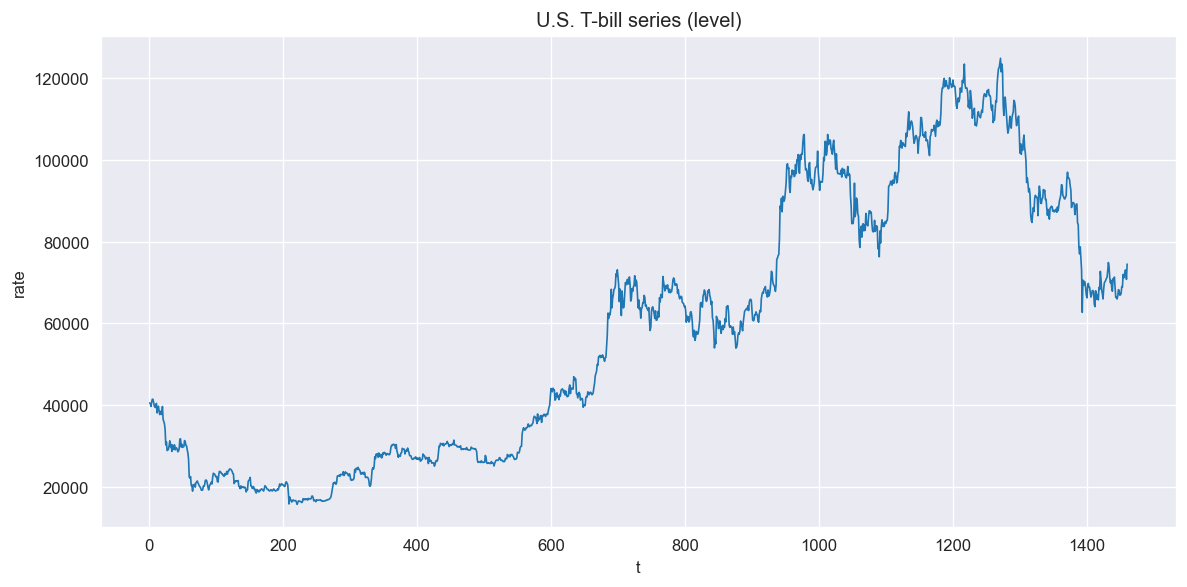

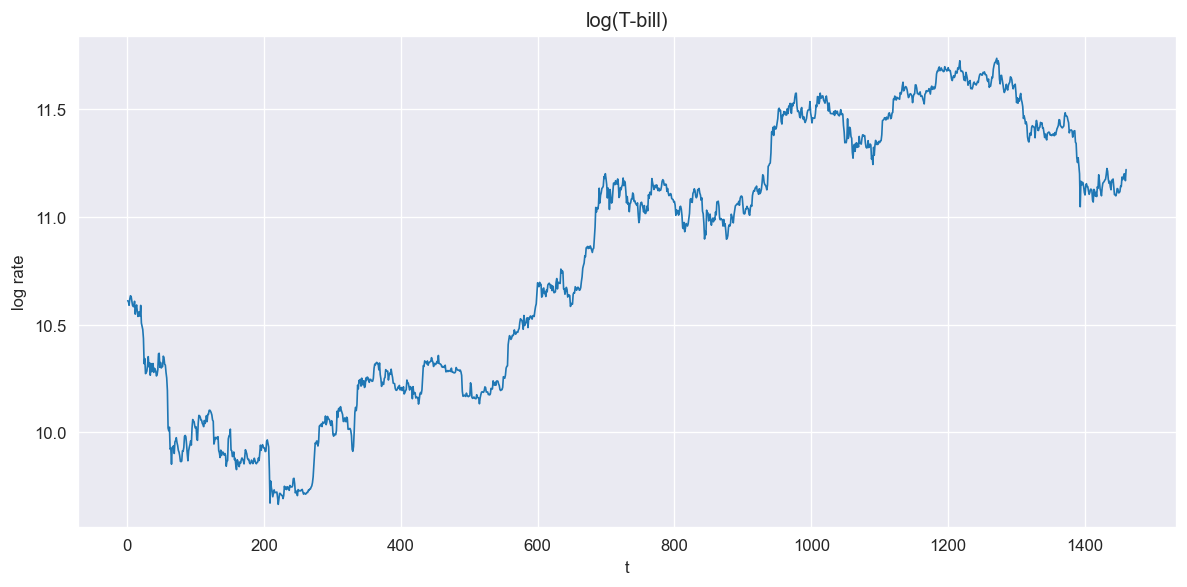

In [20]:
BTC_data=pd.read_excel("Macro_BTC_Dataset.xlsx","Sheet1")
BTC_data.head(10)
BTC_series=BTC_data["BTC_Close"].to_numpy().T.reshape(-1).astype(float)
BTC_series_len = len(BTC_series)
print("Number of monthly observations:", BTC_series_len)
print("First 10 observations:", BTC_series[:10])
print("Last 10 observations:", BTC_series[-10:])
plot_series(BTC_series, "U.S. T-bill series (level)", ylabel="rate")
plot_series(np.log(BTC_series), "log(T-bill)", ylabel="log rate")

Unit root test summary: level series


C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,BTC_series,ADF (constant),-0.911011,0.784325,1
1,BTC_series,KPSS (constant),4.929500,0.010000,25
2,BTC_series,ADF (constant + trend),-1.809649,0.700087,1
3,BTC_series,KPSS (constant + trend),0.424951,0.010000,25


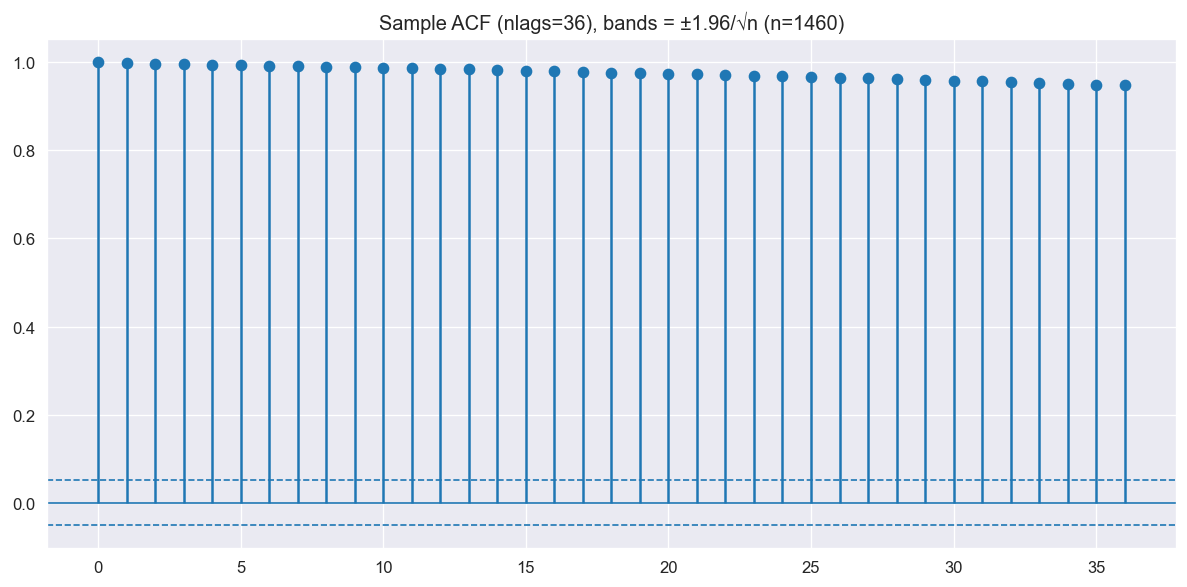

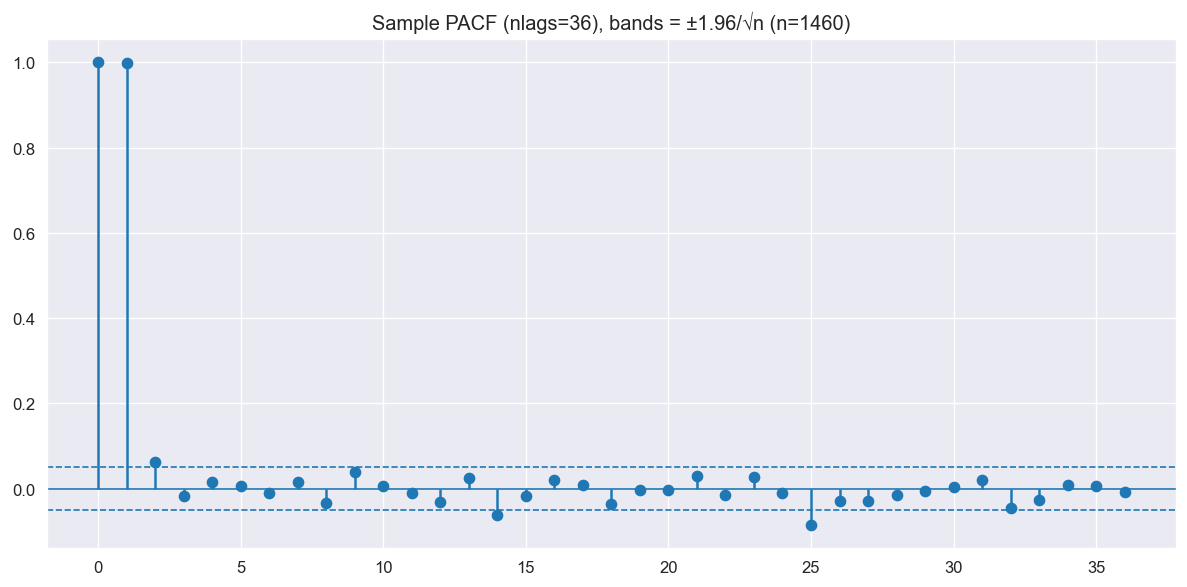

(array([1.    , 0.9986, 0.9974, 0.9961, 0.9949, 0.9936, 0.9924, 0.9912,
        0.9899, 0.9887, 0.9875, 0.9863, 0.9851, 0.9839, 0.9825, 0.9811,
        0.9797, 0.9784, 0.977 , 0.9756, 0.9741, 0.9728, 0.9714, 0.9701,
        0.9688, 0.9672, 0.9656, 0.9638, 0.9621, 0.9604, 0.9586, 0.957 ,
        0.9552, 0.9533, 0.9515, 0.9497, 0.9479]),
 array([ 1.    ,  0.9986,  0.0628, -0.0166,  0.0159,  0.0069, -0.0109,
         0.0165, -0.0347,  0.0387,  0.0053, -0.0111, -0.0307,  0.0253,
        -0.0626, -0.0164,  0.0198,  0.0087, -0.0351, -0.0023, -0.0041,
         0.0293, -0.0152,  0.026 , -0.0095, -0.0859, -0.0282, -0.0296,
        -0.0154, -0.0048,  0.0048,  0.0205, -0.0452, -0.0264,  0.009 ,
         0.0064, -0.0081]))

In [21]:
print("Unit root test summary: level series")
display(unit_root_summary(BTC_series, name="BTC_series"))
plot_acf_pacf(BTC_series, nlags=36)

Unit root test summary: log series


C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,log(BTC_series),ADF (constant),-0.717468,0.842173,2
1,log(BTC_series),KPSS (constant),5.093314,0.010000,25
2,log(BTC_series),ADF (constant + trend),-2.420974,0.368529,2
3,log(BTC_series),KPSS (constant + trend),0.504990,0.010000,25


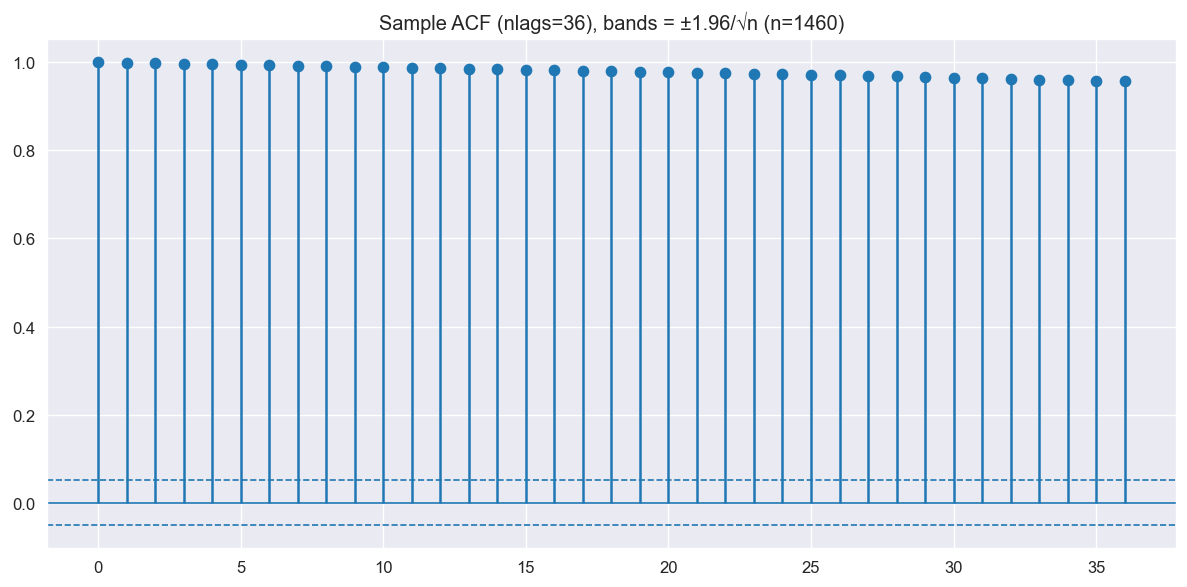

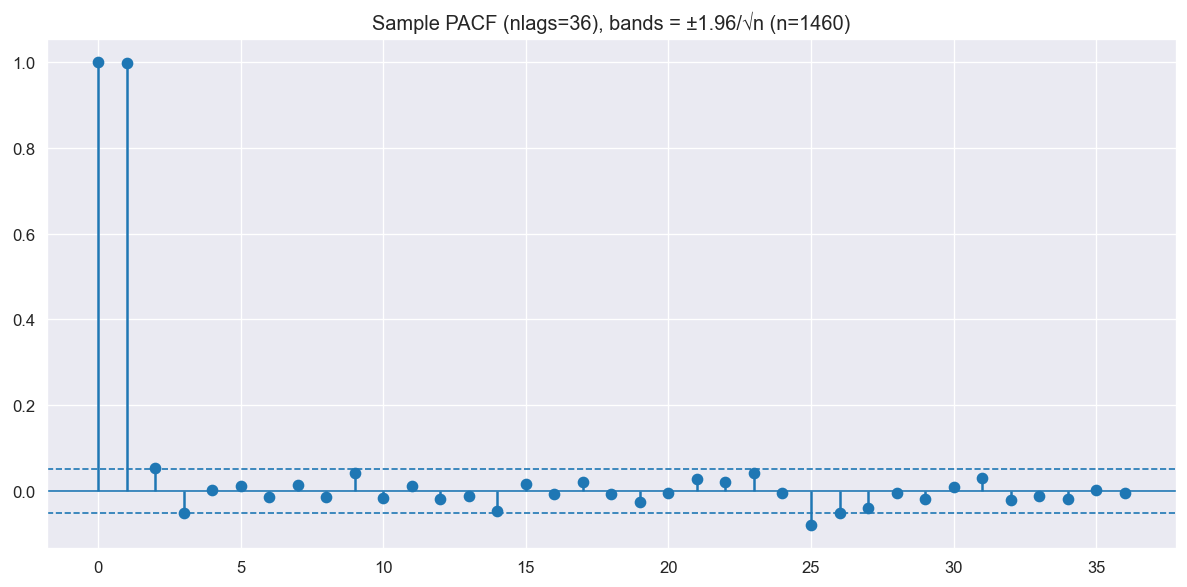

(array([1.    , 0.9989, 0.9979, 0.9968, 0.9957, 0.9946, 0.9935, 0.9925,
        0.9914, 0.9903, 0.9893, 0.9882, 0.9872, 0.9861, 0.9849, 0.9837,
        0.9826, 0.9814, 0.9803, 0.9791, 0.9778, 0.9767, 0.9756, 0.9745,
        0.9735, 0.9723, 0.971 , 0.9696, 0.9682, 0.9668, 0.9653, 0.9639,
        0.9625, 0.9611, 0.9596, 0.9582, 0.9567]),
 array([ 1.    ,  0.9989,  0.0522, -0.0527,  0.0007,  0.0103, -0.0146,
         0.0122, -0.0141,  0.0406, -0.0178,  0.0104, -0.0189, -0.0125,
        -0.048 ,  0.0161, -0.0066,  0.0199, -0.0088, -0.0269, -0.0066,
         0.028 ,  0.0199,  0.0408, -0.0045, -0.0806, -0.0515, -0.0402,
        -0.0062, -0.0184,  0.0083,  0.0301, -0.0221, -0.0132, -0.0201,
         0.0021, -0.0044]))

In [22]:
print("Unit root test summary: log series")
display(unit_root_summary(np.log(BTC_series), name="log(BTC_series)"))
plot_acf_pacf(np.log(BTC_series), nlags=36)

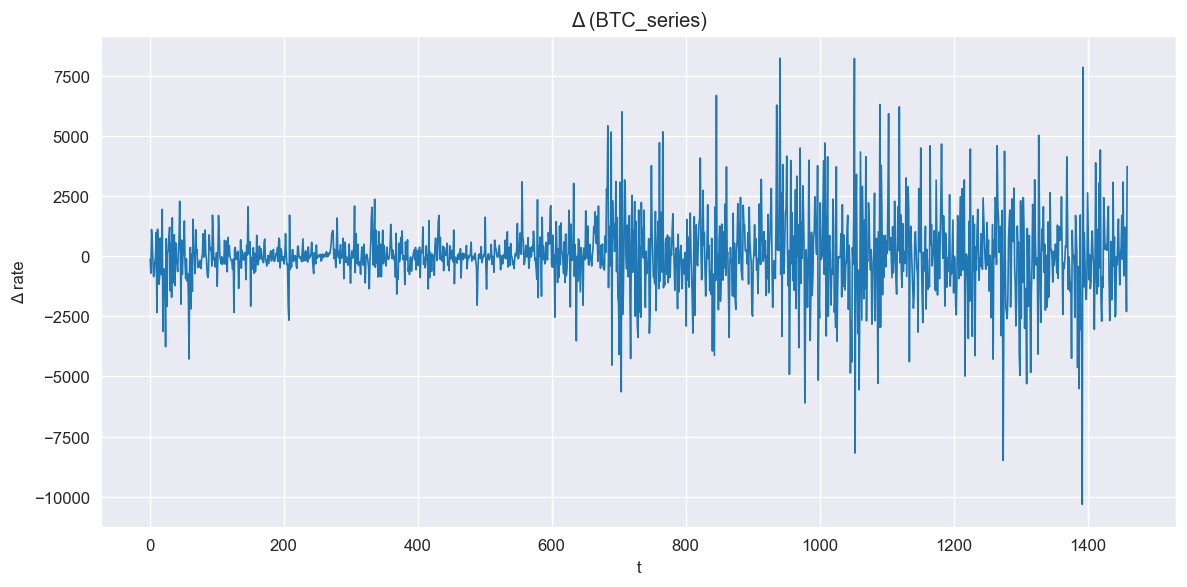

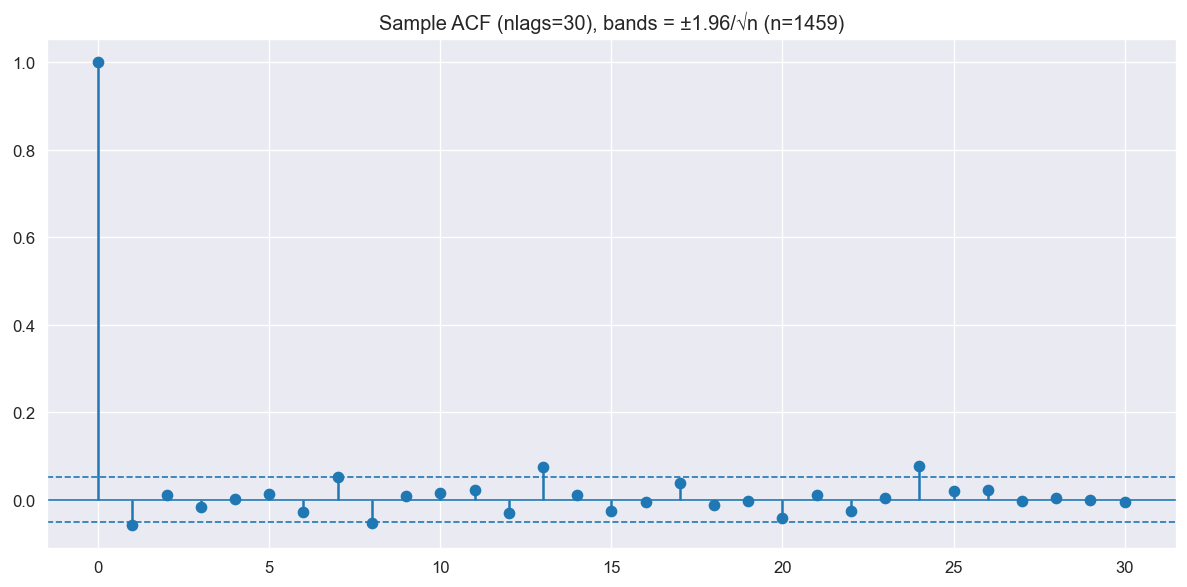

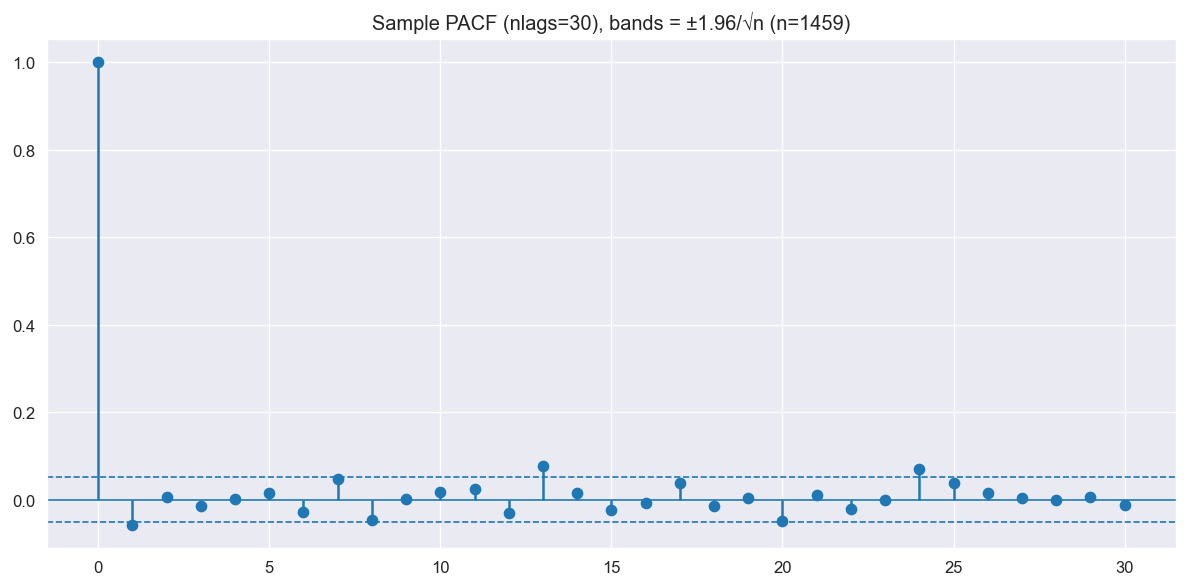

Unit root test summary: Δ log(BTC_series)


C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,dlBTC_series,ADF (constant),-40.384393,0.000000,0
1,dlBTC_series,KPSS (constant),0.157452,0.100000,0
2,dlBTC_series,ADF (constant + trend),-40.370544,0.000000,0
3,dlBTC_series,KPSS (constant + trend),0.157082,0.040765,0


In [23]:
dBTC_series = np.diff((BTC_series))
plot_series(dBTC_series, "Δ (BTC_series)", ylabel="Δ rate")
plot_acf_pacf(dBTC_series, nlags=30)

print("Unit root test summary: Δ log(BTC_series)")
display(unit_root_summary(dBTC_series, name="dlBTC_series"))

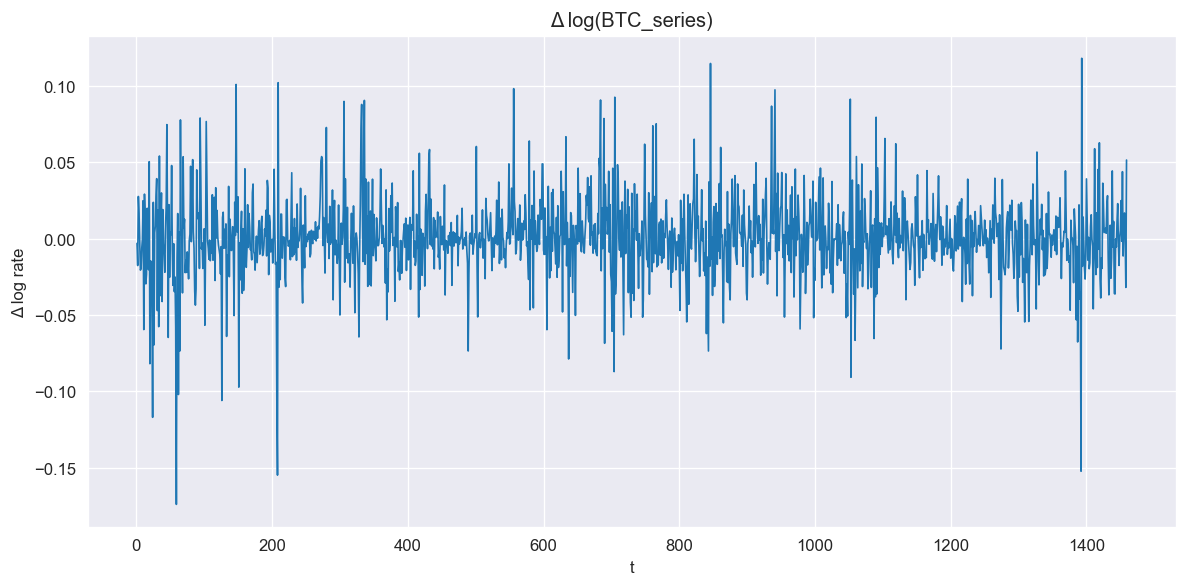

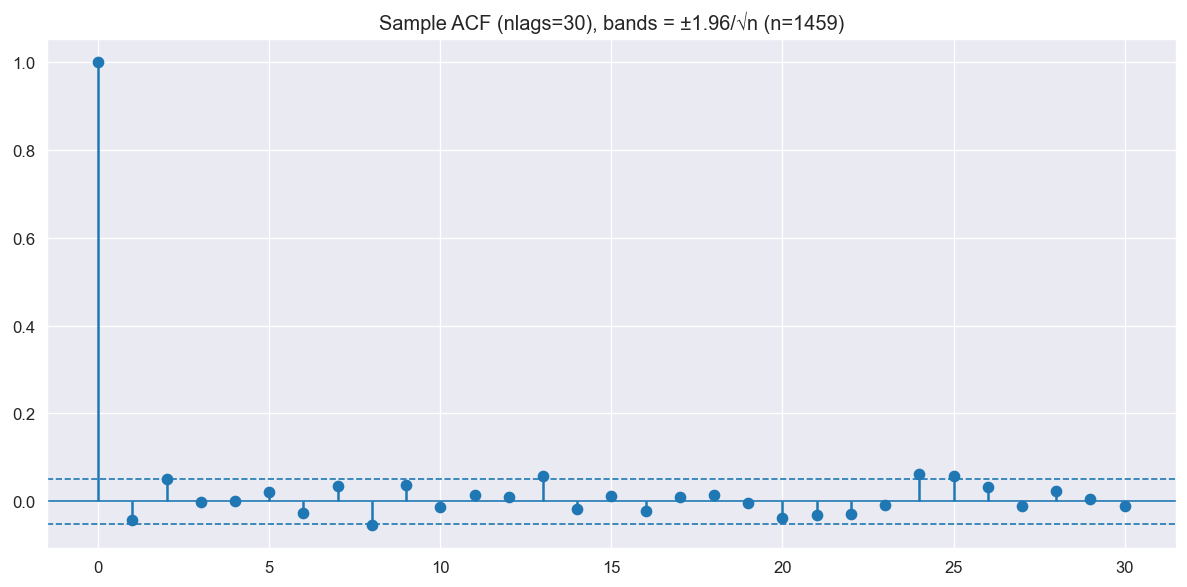

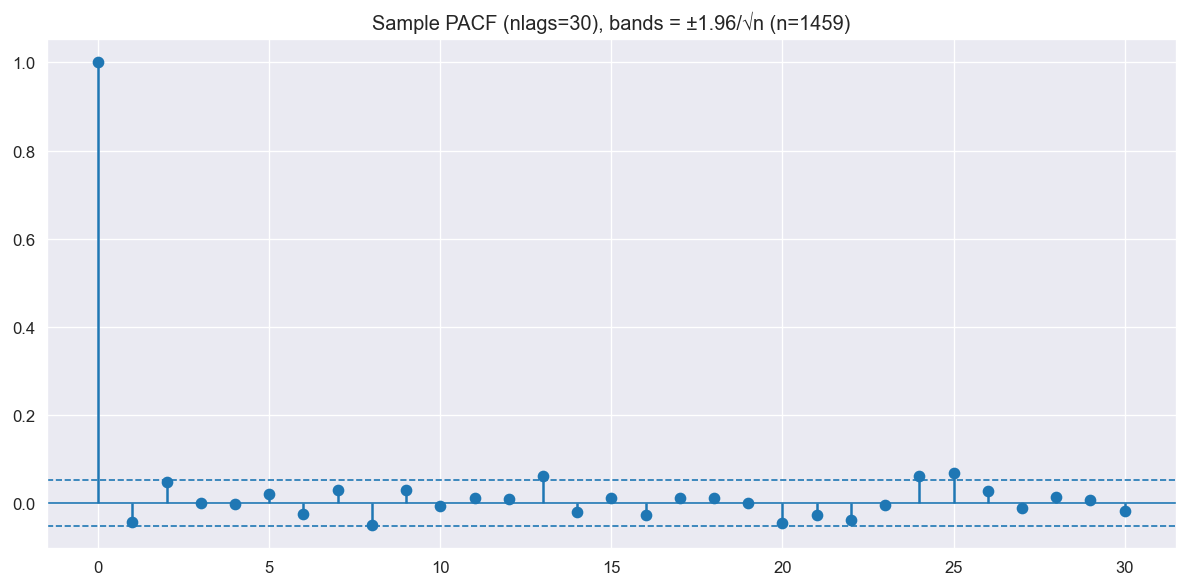

Unit root test summary: Δ log(BTC_series)


C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
C:\Users\wolff\AppData\Local\Temp\ipykernel_21636\1030154294.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,dlBTC_series,ADF (constant),-26.242973,0.00,1
1,dlBTC_series,KPSS (constant),0.227049,0.10,5
2,dlBTC_series,ADF (constant + trend),-26.237386,0.00,1
3,dlBTC_series,KPSS (constant + trend),0.223064,0.01,5


In [24]:
dlBTC_series = np.diff(np.log(BTC_series))
plot_series(dlBTC_series, "Δ log(BTC_series)", ylabel="Δ log rate")
plot_acf_pacf(dlBTC_series, nlags=30)

print("Unit root test summary: Δ log(BTC_series)")
display(unit_root_summary(dlBTC_series, name="dlBTC_series"))


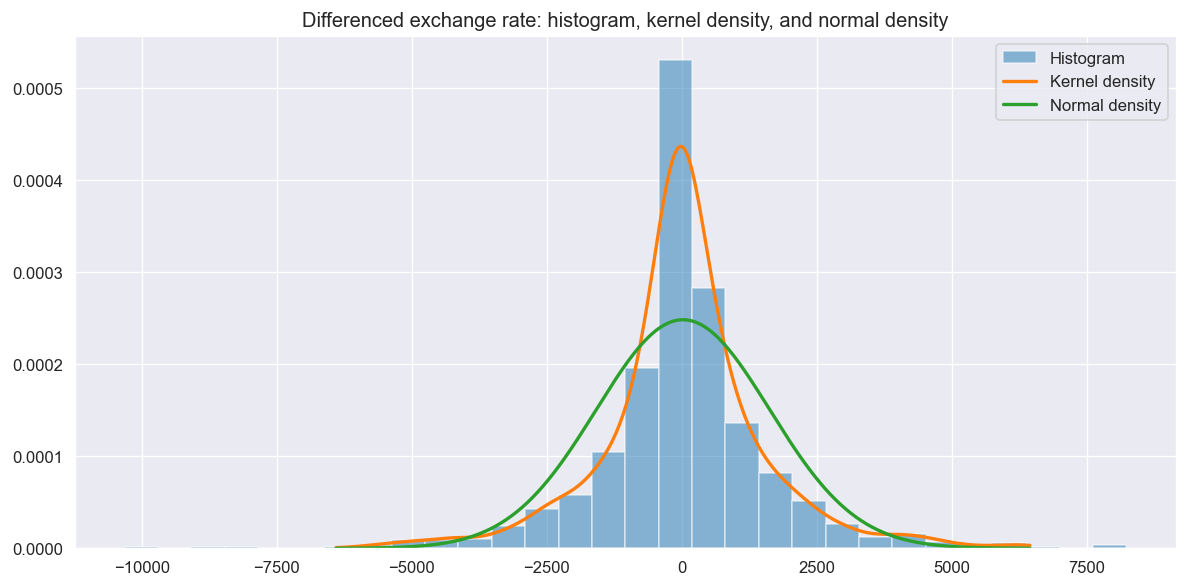

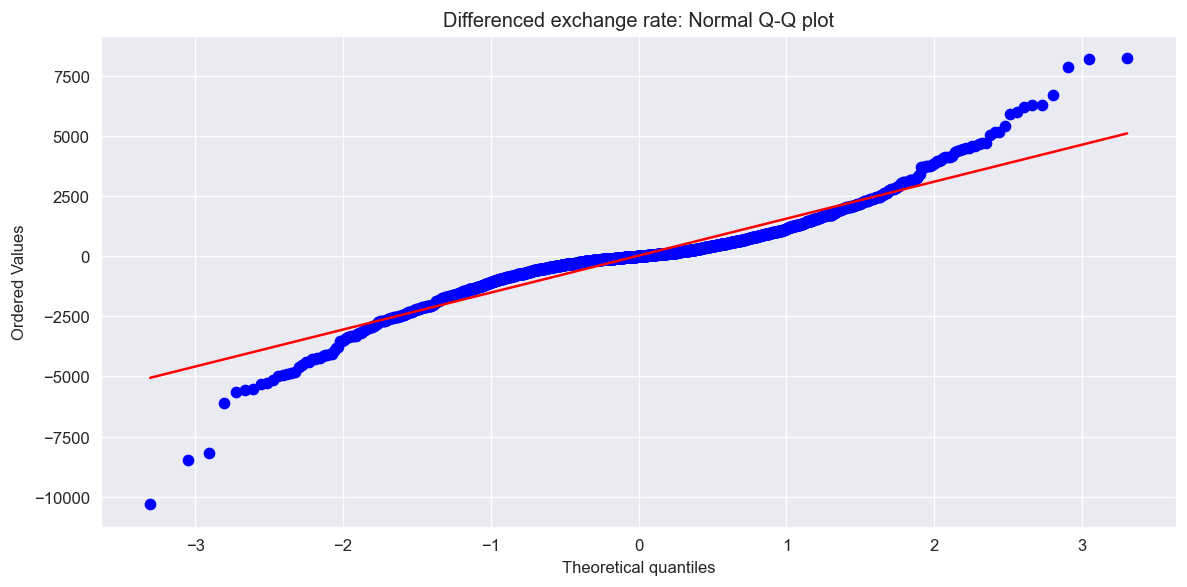

In [25]:
plot_hist_density_qq(dBTC_series, title_prefix="Differenced exchange rate")

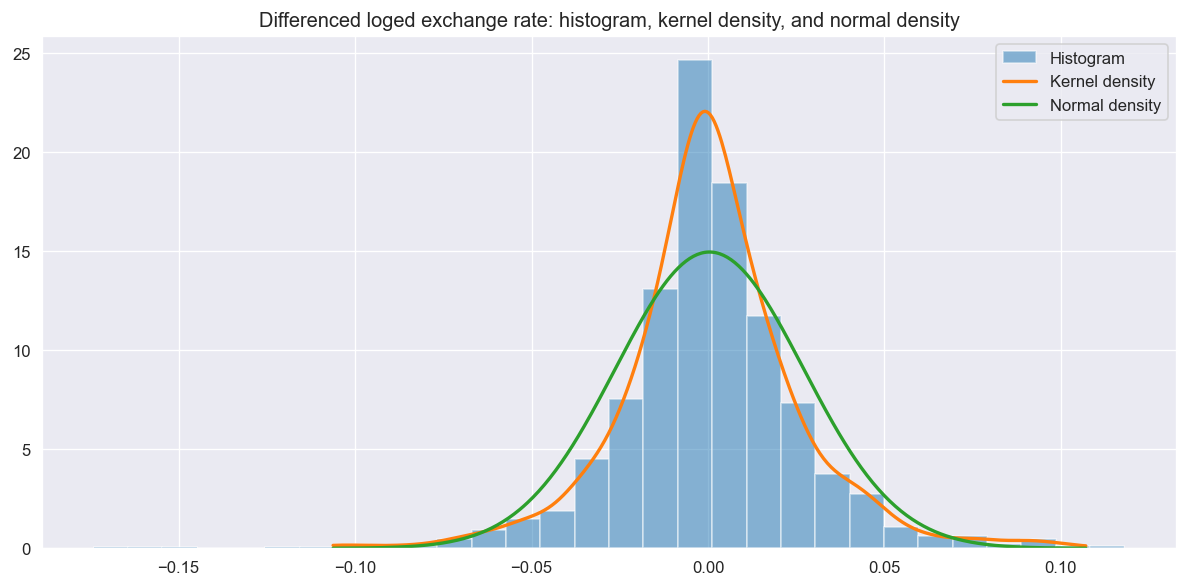

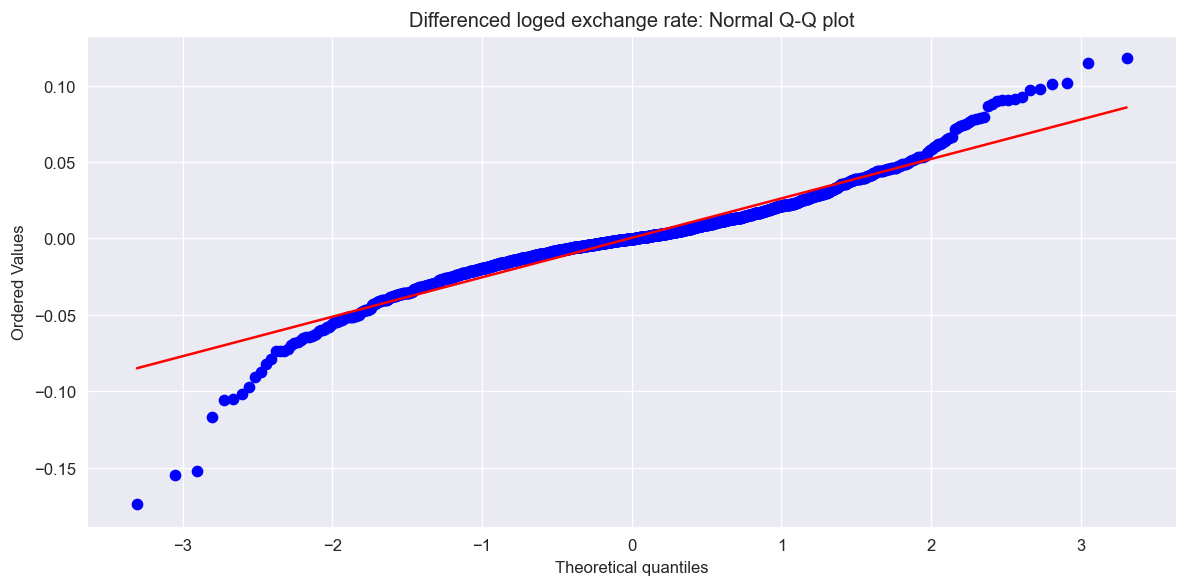

In [26]:
plot_hist_density_qq(dlBTC_series, title_prefix="Differenced loged exchange rate")

      lb_stat  lb_pvalue
1    2.767956   0.096169
2    6.362229   0.041539
3    6.374802   0.094733
4    6.375206   0.172825
5    6.979977   0.222134
6    8.028037   0.236056
7    9.696159   0.206456
8   14.137829   0.078243
9   16.171695   0.063382
10  16.461376   0.087165
11  16.791213   0.114205
12  16.924892   0.152445
13  21.724804   0.059775
14  22.207018   0.074460
15  22.422813   0.097187
16  23.213182   0.108153
17  23.348036   0.138259
18  23.608600   0.168273
19  23.643025   0.210204
20  25.915047   0.168636
21  27.508372   0.154653
22  28.882909   0.148234
23  28.999604   0.180323
24  34.857993   0.070534
25  39.780717   0.030713
26  41.296221   0.028969
27  41.475340   0.037049
28  42.318415   0.040454
29  42.340809   0.052317
30  42.551614   0.064142
31  43.259342   0.070603
32  43.307508   0.087573
33  43.499296   0.104483
34  43.506048   0.127293
35  43.627289   0.150304
36  44.735060   0.150690
37  44.742816   0.178700
38  45.389940   0.191159
39  45.405710   0.222550


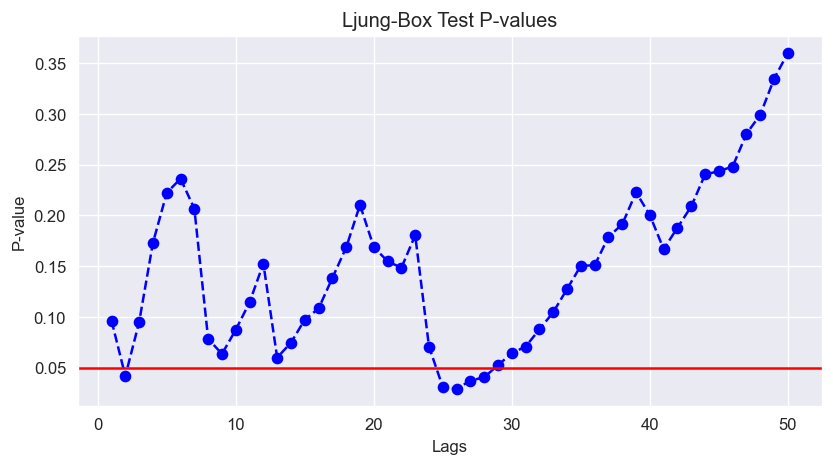

In [27]:
# 从时间可加性上 考虑
#时间可加性（Additivity）：这是最核心的优点。如果你预测了未来 5 天的对数收益率，加起来就是这 5 天的总收益。而原始收益率则需要进行复杂的相乘计算，这会导致模型误差在多步预测中产生非线性累积。
import matplotlib.pyplot as plt
# 检验 1 到 10 阶
res = acorr_ljungbox(dlBTC_series, lags=50, return_df=True)
# 打印结果
print(res)
# 可视化 P 值
plt.figure(figsize=(8, 4))
plt.plot(res.index, res['lb_pvalue'], marker='o', linestyle='--', color='b')
plt.axhline(y=0.05, color='r', linestyle='-') # 0.05 显著性水平线
plt.title('Ljung-Box Test P-values')
plt.xlabel('Lags')
plt.ylabel('P-value')
plt.show()

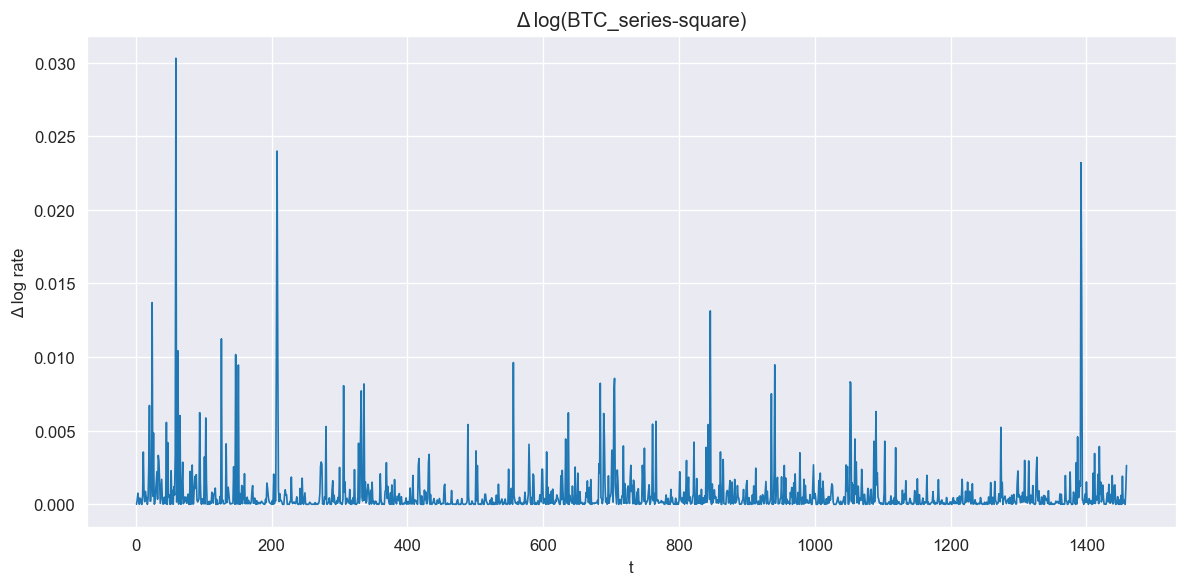

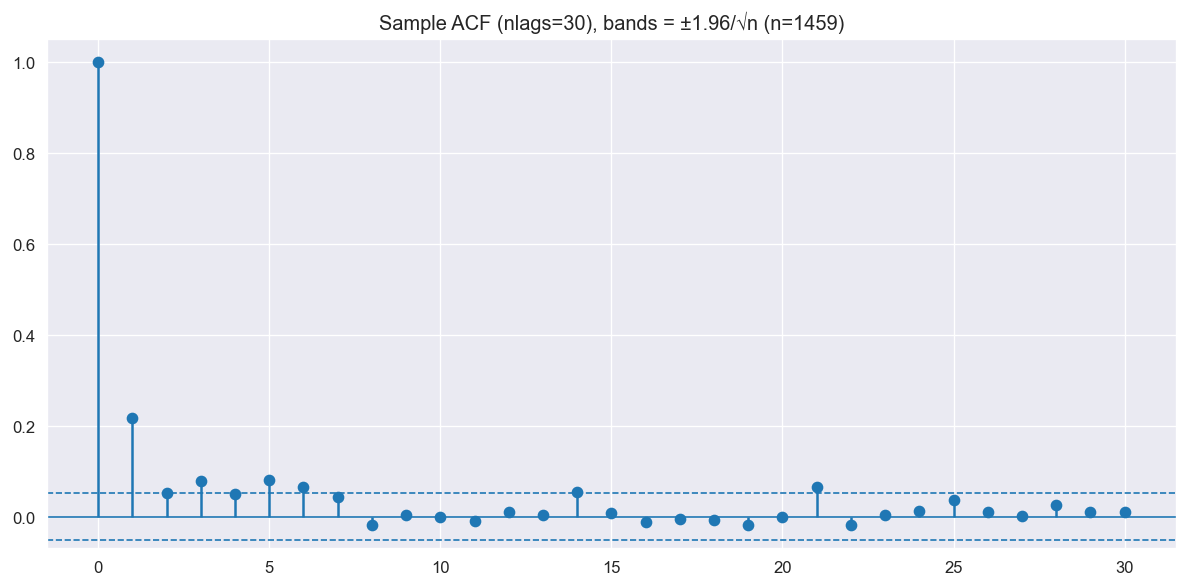

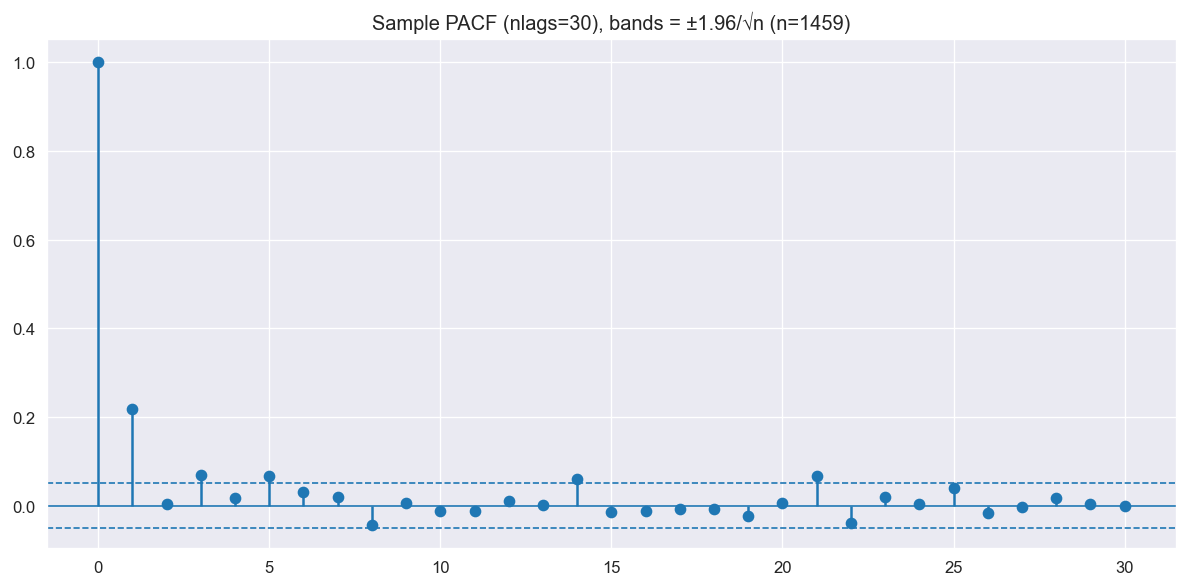

Unit root test summary: Δ log(BTC_series-square)


,series,test,stat,pvalue,usedlag
0,dlBTC_series_sq,ADF (constant),-14.185406,1.896708e-26,4
1,dlBTC_series_sq,KPSS (constant),0.502078,4.119874e-02,14
2,dlBTC_series_sq,ADF (constant + trend),-14.341553,5.696236e-22,4
3,dlBTC_series_sq,KPSS (constant + trend),0.149639,4.696721e-02,14


In [28]:
# GARCH
dlBTC_series_sq = dlBTC_series ** 2

plot_series(dlBTC_series_sq, "Δ log(BTC_series-square)", ylabel="Δ log rate")
plot_acf_pacf(dlBTC_series_sq, nlags=30)

print("Unit root test summary: Δ log(BTC_series-square)")
display(unit_root_summary(dlBTC_series_sq, name="dlBTC_series_sq"))

In [29]:
lm_tbl = arch_lm_table(dlBTC_series_sq, nlags=4)
lm_tbl
#If the p-value is small, the null of no ARCH effect is rejected. Then the conditional variance depends on the past, so a GARCH-type model is appropriate.

,LM stat,LM p-value,F stat,F p-value,lags
0,35.147664,4.331948e-07,8.973488,3.699326e-07,4



### Step 5: Compare ARCH(1) and GARCH(1,1)
To keep the notebook self-contained, we fit Gaussian QMLE versions of:
- ARCH(1)
- GARCH(1,1)

The GARCH(1,1) fit should be close to the textbook result:
$$
\hat\sigma_t^2 \approx 3.1\times 10^{-5} + 0.067 X_{t-1}^2 + 0.89\,\hat\sigma_{t-1}^2.
$$


In [30]:
arch1 = fit_arch1(dlBTC_series)
garch11 = fit_garch11(dlBTC_series)

cmp_vol = pd.DataFrame({
    "model": ["ARCH(1)", "GARCH(1,1)"],
    "omega": [arch1["omega"], garch11["omega"]],
    "alpha": [arch1["alpha"], garch11["alpha"]],
    "beta": [np.nan, garch11["beta"]],
    "AIC": [arch1["aic"], garch11["aic"]],
    "BIC": [arch1["bic"], garch11["bic"]]
})
cmp_vol

,model,omega,alpha,beta,AIC,BIC
0,ARCH(1),0.000534,0.266072,NaN,-9215.825587,-9205.254574
1,"GARCH(1,1)",0.000119,0.173470,0.666417,-9256.388709,-9240.532189


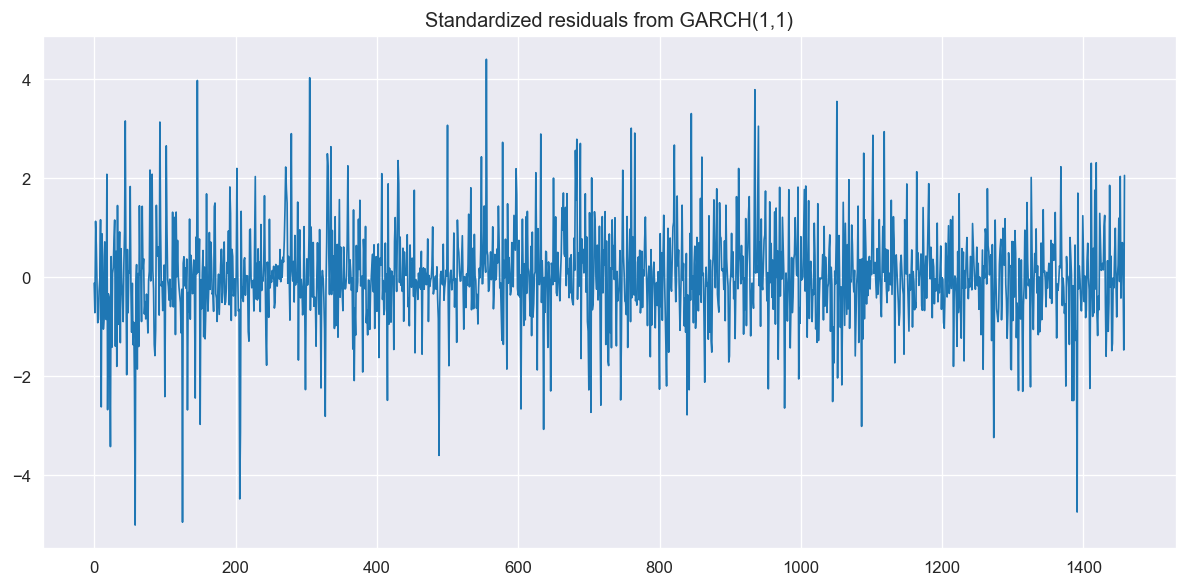

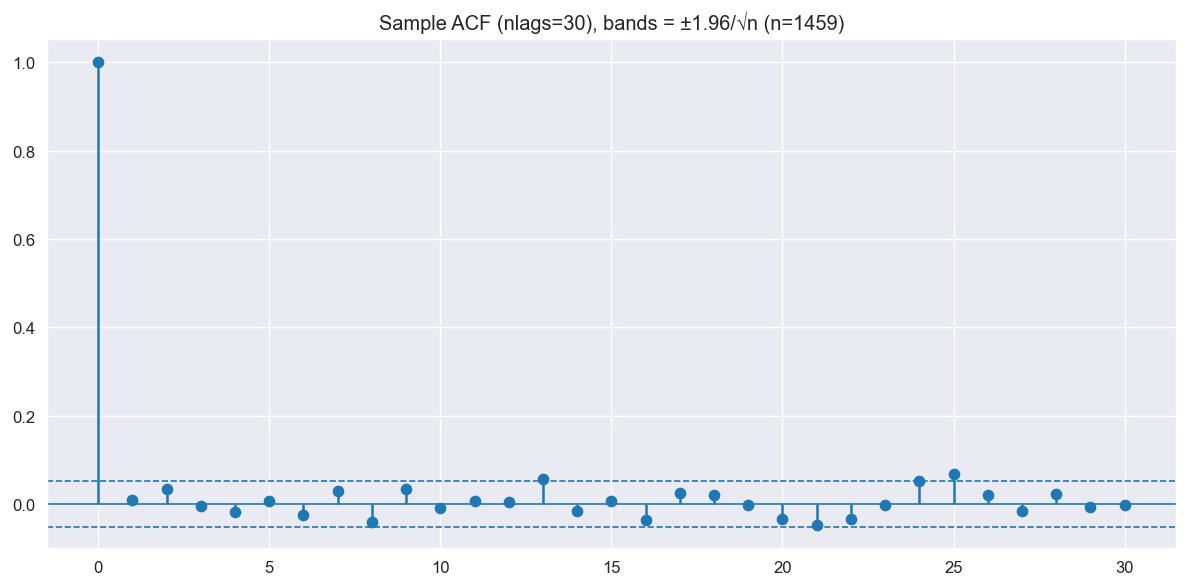

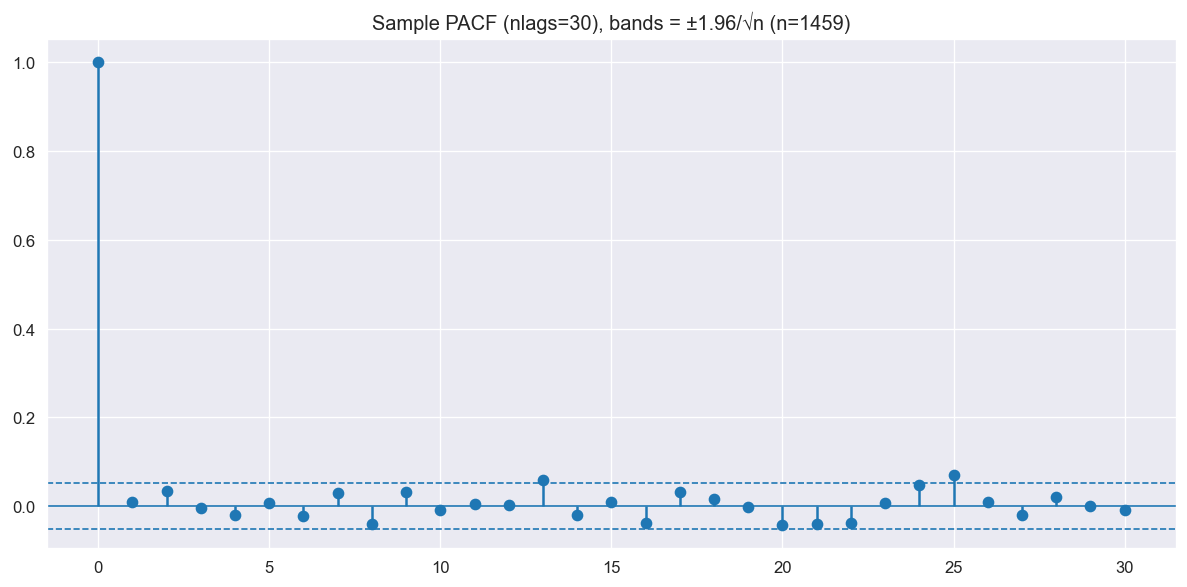

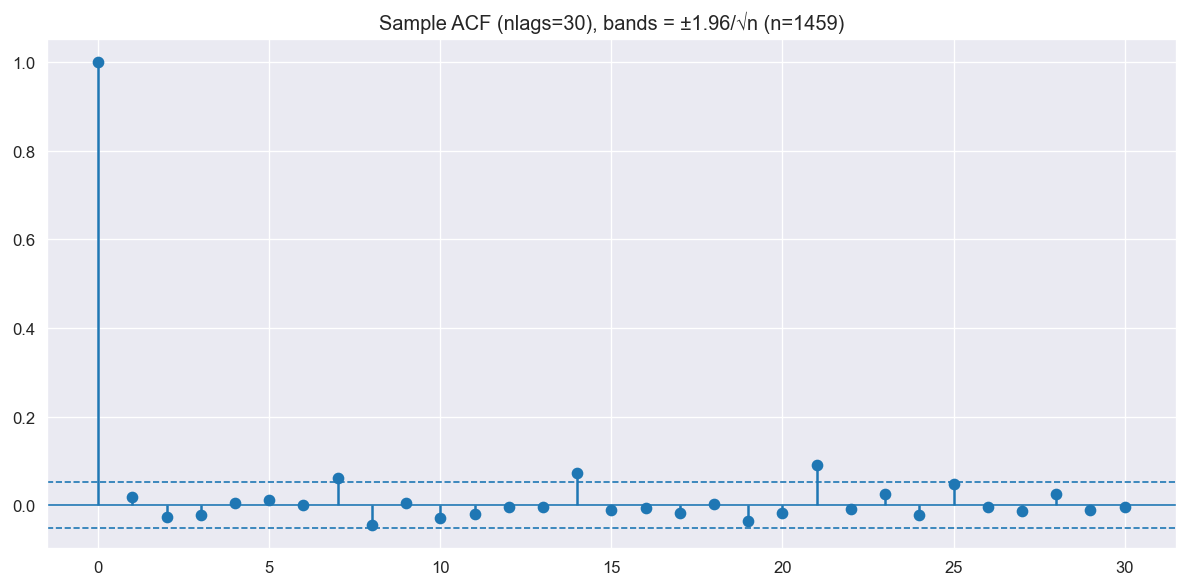

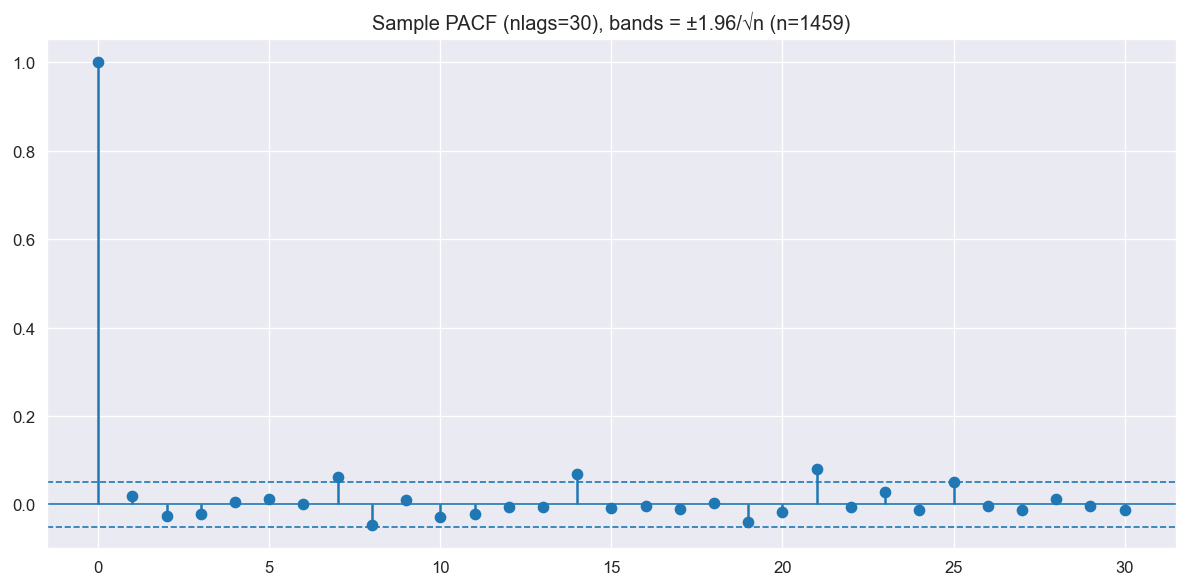

(array([ 1.    ,  0.018 , -0.0269, -0.0228,  0.0048,  0.0125,  0.0013,
         0.0615, -0.0452,  0.0046, -0.0285, -0.0196, -0.0042, -0.0041,
         0.0718, -0.0118, -0.0058, -0.0182,  0.0037, -0.035 , -0.018 ,
         0.0897, -0.0079,  0.0251, -0.0216,  0.0477, -0.003 , -0.0126,
         0.0251, -0.0102, -0.0052]),
 array([ 1.    ,  0.018 , -0.0273, -0.0218,  0.0049,  0.0111,  0.0007,
         0.0624, -0.0472,  0.0097, -0.0289, -0.0209, -0.0057, -0.0052,
         0.0678, -0.0085, -0.0041, -0.0115,  0.0025, -0.0391, -0.0173,
         0.0802, -0.0066,  0.0289, -0.0138,  0.0504, -0.003 , -0.0134,
         0.0113, -0.0042, -0.0121]))

In [31]:
std_resid = garch11["resid"]

plt.figure(figsize=(10,5))
plt.plot(std_resid, linewidth=1)
plt.title("Standardized residuals from GARCH(1,1)")
plt.tight_layout()
plt.show()

plot_acf_pacf(std_resid, nlags=30)
plot_acf_pacf(std_resid**2, nlags=30)


      lb_stat  lb_pvalue
1    0.104888   0.746041
2    1.870289   0.392529
3    1.890209   0.595504
4    2.423244   0.658431
5    2.503534   0.775963
6    3.359752   0.762526
7    4.706525   0.695726
8    7.150321   0.520505
9    8.772853   0.458501
10   8.925735   0.539166
11   8.991003   0.622723
12   9.030147   0.700353
13  13.730199   0.393115
14  14.052371   0.445817
15  14.133079   0.515461
16  15.975774   0.454653
17  16.880595   0.462484
18  17.438995   0.493143
19  17.453683   0.559161
20  19.231851   0.506805
21  22.654259   0.362686
22  24.376382   0.327814
23  24.388587   0.382559
24  28.575947   0.236499
25  35.525216   0.079119
26  36.186884   0.088285
27  36.547135   0.103836
28  37.361035   0.111110
29  37.446619   0.135142
30  37.457624   0.164177
31  38.331570   0.171141
32  38.563345   0.197015
33  38.577634   0.231968
34  38.582394   0.270065
35  38.594219   0.310356
36  40.915695   0.263469
37  40.994749   0.299593
38  40.997671   0.340431
39  41.051414   0.380725


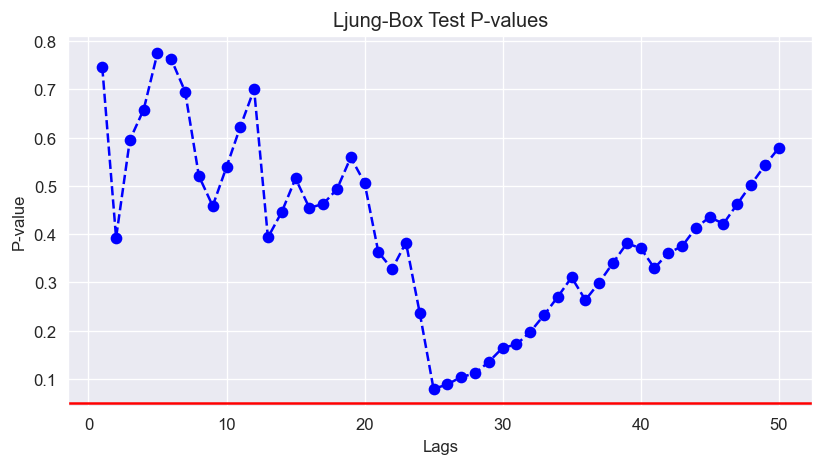

In [32]:
res = acorr_ljungbox(std_resid, lags=50, return_df=True)
# 打印结果
print(res)
# 可视化 P 值
plt.figure(figsize=(8, 4))
plt.plot(res.index, res['lb_pvalue'], marker='o', linestyle='--', color='b')
plt.axhline(y=0.05, color='r', linestyle='-') # 0.05 显著性水平线
plt.title('Ljung-Box Test P-values')
plt.xlabel('Lags')
plt.ylabel('P-value')
plt.show()

ARCH-LM test on squared standardized residuals


,LM stat,LM p-value,F stat,F p-value,lags
0,0.473176,0.49153,0.47268,0.491866,1


,LM stat,LM p-value,F stat,F p-value,lags
0,1.552897,0.460037,0.775676,0.460583,2


,LM stat,LM p-value,F stat,F p-value,lags
0,2.245314,0.523078,0.747535,0.523792,3


,LM stat,LM p-value,F stat,F p-value,lags
0,2.288301,0.6829,0.571007,0.683719,4


,LM stat,LM p-value,F stat,F p-value,lags
0,2.461785,0.782239,0.491157,0.78307,5


,LM stat,LM p-value,F stat,F p-value,lags
0,2.459728,0.872947,0.408671,0.873653,6


,LM stat,LM p-value,F stat,F p-value,lags
0,8.129612,0.321304,1.161477,0.321997,7


,LM stat,LM p-value,F stat,F p-value,lags
0,11.341098,0.183111,1.419943,0.183245,8


,LM stat,LM p-value,F stat,F p-value,lags
0,11.466745,0.245067,1.275382,0.245448,9


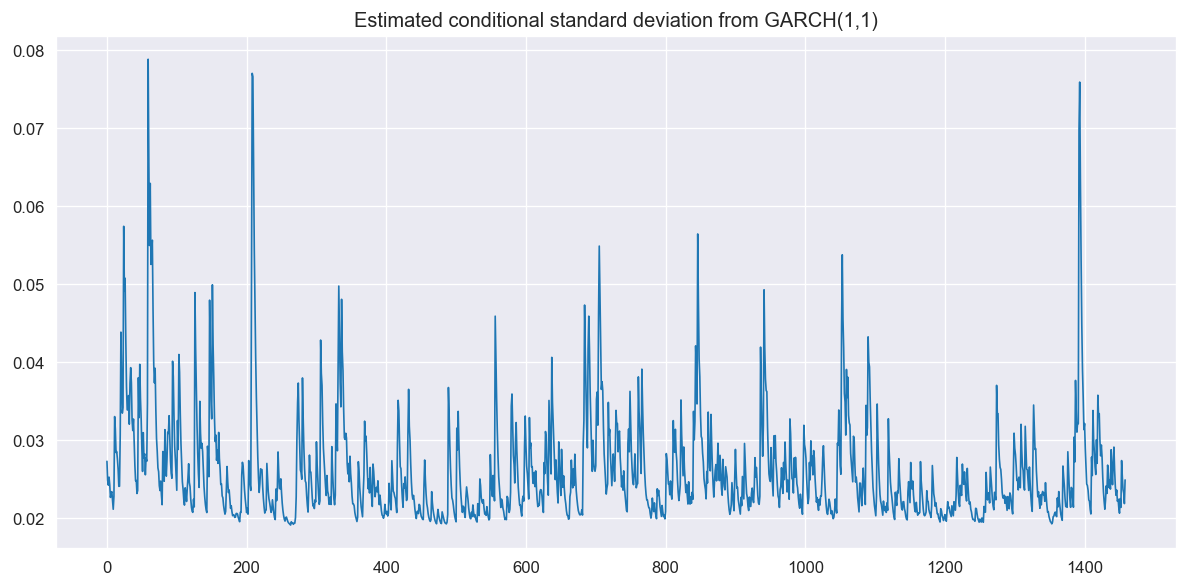

In [33]:

print("ARCH-LM test on squared standardized residuals")
for i in range (1,10):
    display(arch_lm_table(std_resid, nlags=i))


plt.figure(figsize=(10,5))
plt.plot(np.sqrt(garch11["h"]), linewidth=1)
plt.title("Estimated conditional standard deviation from GARCH(1,1)")
plt.tight_layout()
plt.show()

In [34]:
vf = garch_forecast_path(garch11, dlBTC_series_sq, steps=12)
vol_fc = pd.DataFrame({
    "forecast_variance": vf,
    "forecast_std": np.sqrt(vf)
}, index=np.arange(len(dlBTC_series_sq)+1, len(dlBTC_series_sq)+13))
vol_fc

,forecast_variance,forecast_std
1460,0.000534,0.023103
1461,0.000568,0.023825
1462,0.000596,0.024414
1463,0.000620,0.024899
1464,0.000640,0.025299
1465,0.000657,0.025630
1466,0.000671,0.025905
1467,0.000683,0.026133
1468,0.000693,0.026323
1469,0.000701,0.026482


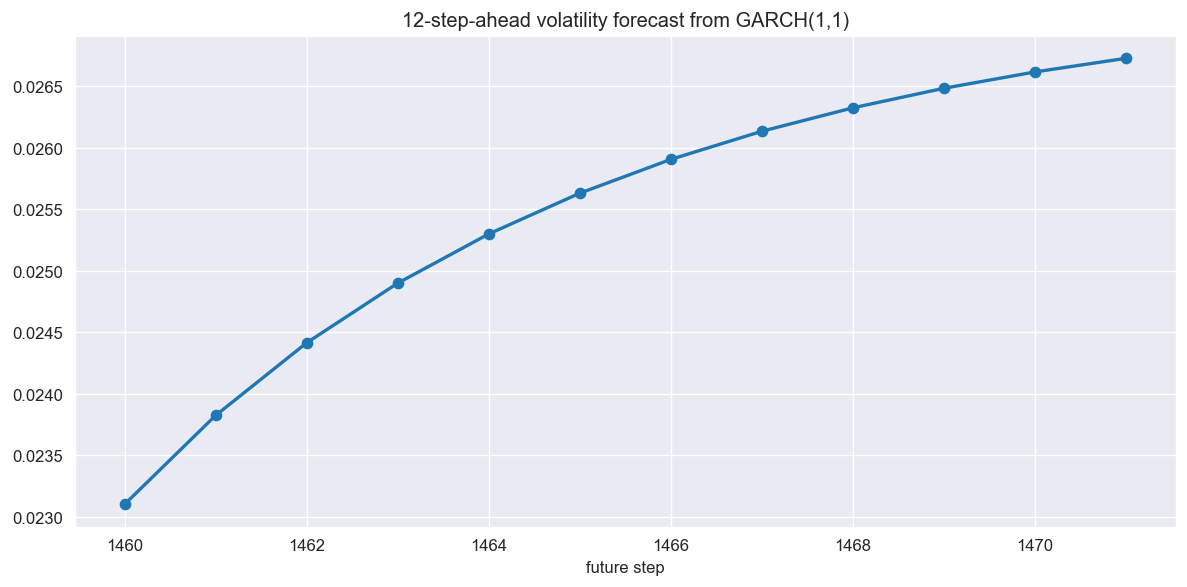

In [35]:
plt.figure(figsize=(10,5))
plt.plot(vol_fc.index, vol_fc["forecast_std"].values, marker="o", linewidth=2)
plt.title("12-step-ahead volatility forecast from GARCH(1,1)")
plt.xlabel("future step")
plt.tight_layout()
plt.show()

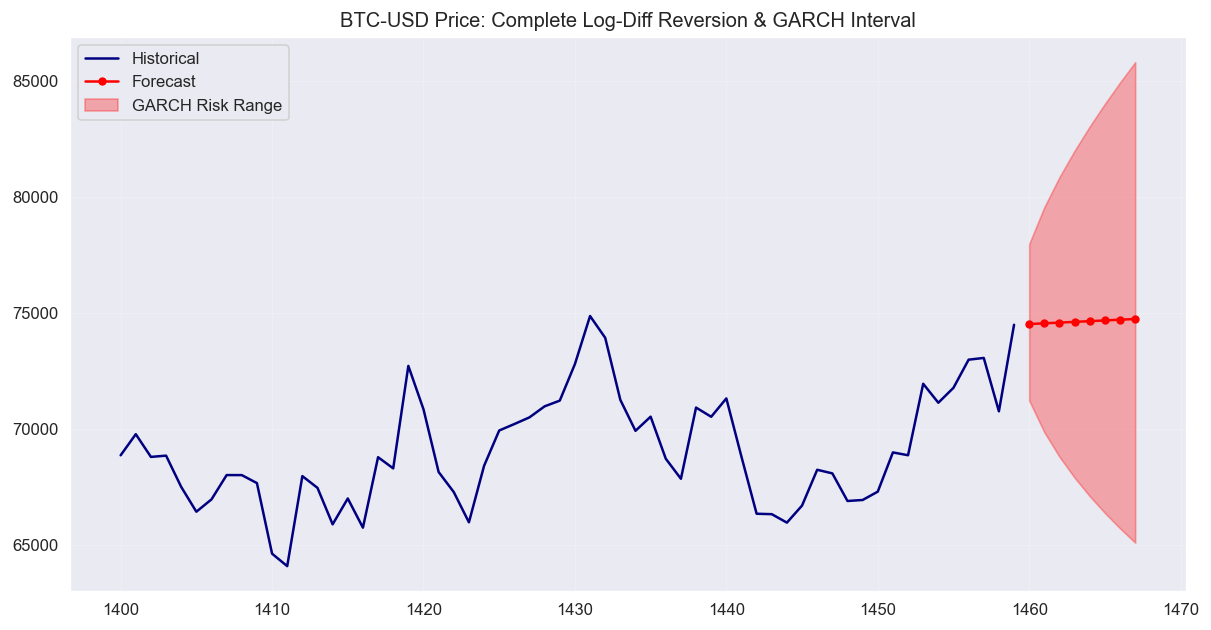

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 参数准备 ---
forecast_steps = 8
last_price = BTC_data['BTC_Close'].iloc[-1]
mu = dlBTC_series.mean()  # 均值
std_forecast = vol_fc['forecast_std'].values[:forecast_steps] # GARCH预测的标准差

# --- 2. 严格的对数差分还原 ---
# 点预测：P_t = P_{t-1} * exp(mu)
predicted_prices = []
curr = last_price
for i in range(forecast_steps):
    curr = curr * np.exp(mu)
    predicted_prices.append(curr)

# 区间预测：根据 log-normal 分布性质还原
# 95% 置信区间在对数空间是 mu ± 1.96*std，还原到价格空间如下：
preds_array = np.array(predicted_prices)
lower_bounds = []
upper_bounds = []
accumulated_mu = 0
accumulated_var = 0

curr_p = last_price
for i in range(forecast_steps):
    # 对数收益率的累加均值和累加方差（因为差分是增量）
    accumulated_mu += mu
    # 注意：方差在独立假设下是累加的
    current_var = vol_fc['forecast_variance'].values[i]
    accumulated_var += current_var

    # 还原价格区间
    # P_T+h = P_T * exp(累加均值 ± 1.96 * sqrt(累加方差))
    l = last_price * np.exp(accumulated_mu - 1.96 * np.sqrt(accumulated_var))
    u = last_price * np.exp(accumulated_mu + 1.96 * np.sqrt(accumulated_var))
    lower_bounds.append(l)
    upper_bounds.append(u)

# --- 3. 绘图 (解决看不见阴影的问题) ---
plt.figure(figsize=(12, 6))

# 历史数据
lookback = 60
history = BTC_data.iloc[-lookback:]
plt.plot(history.index, history['BTC_Close'], label='Historical', color='navy', lw=1.5)
# 预测路径
last_idx = BTC_data.index[-1]
f_indices = np.arange(last_idx + 1, last_idx + forecast_steps + 1)
plt.plot(f_indices, predicted_prices, color='red', marker='o', markersize=4, label='Forecast')
# 绘制阴影 (重点：增加 alpha 和 color 显眼度)
plt.fill_between(f_indices, lower_bounds, upper_bounds, color='red', alpha=0.3, label='GARCH Risk Range')

plt.title("BTC-USD Price: Complete Log-Diff Reversion & GARCH Interval")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [37]:
## use LSTM model to fit the residulal from GARCH
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch

# use bi-lstm to fit the resi

class LSTMResidual(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMResidual, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 1. 禁用双向，改为单向 LSTM
        # dropout=0.2 在 num_layers > 1 时会起作用，防止层间过拟合
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True,
                            bidirectional=False,
                            dropout=0.2)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x 形状: (batch, seq_len, input_size)
        # out 形状: (batch, seq_len, hidden_size)
        # _ 包含了 (h_n, c_n)，即最后时刻的隐藏状态和cell状态
        out, _ = self.lstm(x)
        # 3. 提取最后一个时间步 (last time step) 的输出
        # 在处理 GARCH 残差等时序预测任务时，
        # 索引 -1 确保了我们使用的是截至当前时刻所累积的所有历史信息。
        out = self.fc(out[:, -1, :])
        return out


test_model = LSTMResidual(input_size=1, hidden_size=64, num_layers=2)
test_input = torch.randn(32, 10, 1)
test_output = test_model(test_input)

print(f"输入形状: {test_input.shape}")
print(f"输出形状: {test_output.shape}") # 应该是 [32, 1]


输入形状: torch.Size([32, 10, 1])
输出形状: torch.Size([32, 1])


[[-0.3602]
 [-1.8074]
 [ 2.713 ]
 [ 1.6019]
 [-0.3515]
 [-2.1101]
 [-2.0028]
 [-0.6818]
 [-0.0858]
 [ 2.4332]]
开始 5 折时间序列交叉验证...

--- Fold 1 ---
Fold 1 结束. Val Loss: 1.201783, Directional Accuracy: 53.78%

--- Fold 2 ---
Fold 2 结束. Val Loss: 1.399782, Directional Accuracy: 53.78%

--- Fold 3 ---
Fold 3 结束. Val Loss: 1.481772, Directional Accuracy: 50.84%

--- Fold 4 ---
Fold 4 结束. Val Loss: 1.152463, Directional Accuracy: 52.10%

--- Fold 5 ---
Fold 5 结束. Val Loss: 1.337729, Directional Accuracy: 53.36%

K-Fold 交叉验证完成!
平均验证 Loss: 1.314706


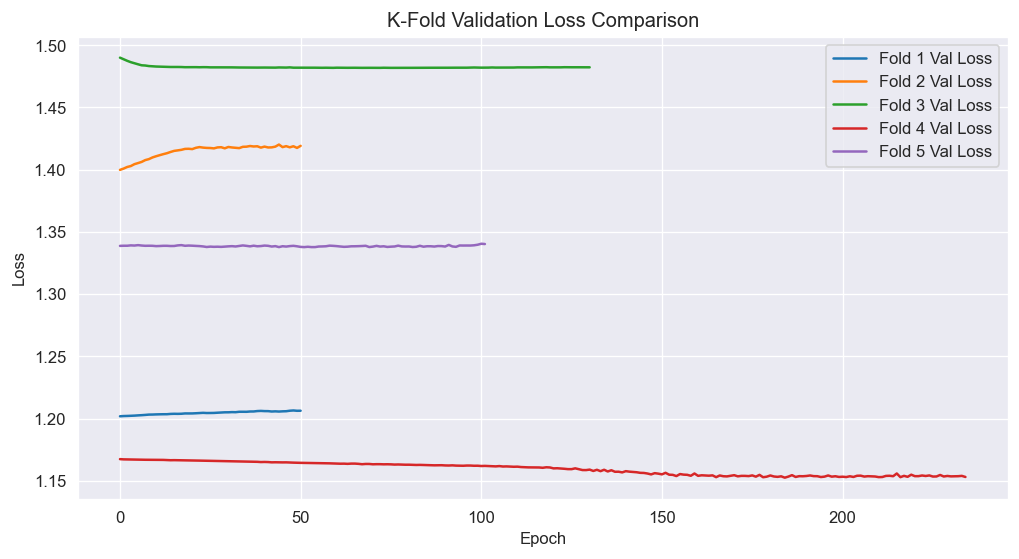

In [38]:
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# --- 1. 物理切分数据 ---
def create_sliding_windows(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

resids = garch11["centered_y"].reshape(-1, 1)
resids_percent=resids * 100
print(resids_percent[0:10])

window_size = 30  # 使用过去n天预测未来一天
X_raw, y_raw = create_sliding_windows(resids_percent, window_size)

n_splits = 5  # 定义 K 折（时间序列折叠）
tscv = TimeSeriesSplit(n_splits=n_splits)

fold_best_losses = []
all_fold_accuracies = []
print(f"开始 {n_splits} 折时间序列交叉验证...")

for fold, (train_index, val_index) in enumerate(tscv.split(X_raw)):
    print(f"\n--- Fold {fold + 1} ---")
    # 1. 按照索引切分数据

    scaler_x = StandardScaler()
    X_train_raw, X_val_raw = X_raw[train_index], X_raw[val_index]
    N_train, W, F = X_train_raw.shape
    X_train_scaled = scaler_x.fit_transform(X_train_raw.reshape(-1, F)).reshape(N_train, W, F)
    N_val = X_val_raw.shape[0]
    X_val_scaled = scaler_x.transform(X_val_raw.reshape(-1, F)).reshape(N_val, W, F)

    X_train_fold = torch.from_numpy(X_train_scaled).float()
    y_train_fold = torch.from_numpy(y_raw[train_index]).float()
    X_val_fold = torch.from_numpy(X_val_scaled).float()
    y_val_fold = torch.from_numpy(y_raw[val_index]).float()

    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold), batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_fold, y_val_fold), batch_size=32, shuffle=False)

    # 2. 重新初始化模型、优化器和调度器
    model = LSTMResidual() # 确保这里用的是你修改后的单向 LSTM
    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-6)
    epochs = 500 # K-fold 时 epoch 可以适当调小或依赖 Early Stopping
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float('inf')
    patience_counter = 0
    fold_history = {'train_loss': [], 'val_loss': []}
    # 3. 训练循环
    for epoch in range(epochs):
        model.train()
        train_epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            train_epoch_loss += loss.item()

        model.eval()
        val_epoch_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                v_out = model(batch_x)
                v_loss = criterion(v_out, batch_y)
                val_epoch_loss += v_loss.item()

        scheduler.step()

        avg_train = train_epoch_loss / len(train_loader)
        avg_val = val_epoch_loss / len(val_loader)
        fold_history['train_loss'].append(avg_train)
        fold_history['val_loss'].append(avg_val)

        # Early Stopping 逻辑
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            # 每一折保存一个专门的模型文件，或者只保留平均表现最好的
            torch.save(model.state_dict(), f'checkpoint_simple/best_model_fold_{fold+1}.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 50: # 缩小 patience 提升效率
                break

    fold_best_losses.append(best_val_loss)
    # 计算该折的方向准确率 (DA)
    model.load_state_dict(torch.load(f'checkpoint_simple/best_model_fold_{fold+1}.pth'))
    model.eval()
    with torch.no_grad():
        final_preds = model(X_val_fold)
        da = np.mean(np.sign(final_preds.numpy()) == np.sign(y_val_fold.numpy()))
    all_fold_accuracies.append(da)

    print(f"Fold {fold+1} 结束. Val Loss: {best_val_loss:.6f}, Directional Accuracy: {da:.2%}")
    # 绘制当前 Fold 的 Loss
    #plt.plot(fold_history['train_loss'], label=f'Fold {fold+1} Train Loss')
    plt.plot(fold_history['val_loss'], label=f'Fold {fold+1} Val Loss')


print(f"\nK-Fold 交叉验证完成!")
print(f"平均验证 Loss: {np.mean(fold_best_losses):.6f}")

plt.title('K-Fold Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from arch import arch_model
from arch.unitroot import ADF, KPSS
def check_all_stationarity(df, columns):
    results = []
    for col in columns:
        stat_test = ADF(df[col])
        results.append({
            'Variable': col,
            'ADF Statistic': round(stat_test.stat, 4),
            'p-value': round(stat_test.pvalue, 4),
            'Stationary': 'Yes' if stat_test.pvalue < 0.05 else 'No'
        })
    return pd.DataFrame(results)


# GARCH Model
price_cols = ['BTC_close', 'ETH_close', 'BNB_close', 'SOL_close', 'XRP_close',
              'DXY_close', 'Dow_close', 'Nasdaq_close', 'SP500_close', 'Oil_close', 'Gold_close', 'FedRate_close']


# 循环计算每一列的对数收益率
for col in price_cols:
    # 公式：ln(P_t) - ln(P_{t-1})
    # shift(1) 是为了对齐前一天的数据
    main_df[f'{col}_ret'] = np.log(main_df[col]) - np.log(main_df[col].shift(1))

main_df = main_df.dropna().reset_index(drop=True)
print(main_df[['BTC_close', 'BTC_close_ret']].head())
# 运行检验
ret_cols = [c for c in main_df.columns if c.endswith('_ret')]
print(check_all_stationarity(main_df, ret_cols))

In [ ]:
# GARCH
y = main_df['BTC_close_ret']
scaled_y = y * 100
model = arch_model(y , mean='Constant', vol='Garch', p=1, q=1, dist='t')
# 执行拟合
res = model.fit(update_freq=5, disp='off')
# 查看结果
print(res.summary())

In [ ]:
# 2. 定义外生变量矩阵 (Exogenous Variables)
# 排除掉目标变量本身，剩下的都是 X
exog_cols = ['DXY_close_ret', 'Dow_close_ret', 'Nasdaq_close_ret',
             'SP500_close_ret', 'Oil_close_ret', 'Gold_close_ret', 'FedRate_close_ret']
X = main_df[exog_cols]
model = arch_model(y, x=X, mean='ARX', lags=1, vol='Garch', p=1, q=1, dist='t')
# 拟合
# update_freq=5 表示每5次迭代显示一次进度
res = model.fit(disp='off', update_freq=5)
# 查看完整报告
print(res.summary())

In [ ]:
# 只保留这三个核心变量
refined_exog = main_df[['Nasdaq_close_ret', 'DXY_close_ret']]
# 重新拟合
final_model = arch_model(y, x=refined_exog, mean='ARX', lags=1, vol='Garch', p=1, q=1, dist='t')
final_res = final_model.fit(disp='off')
print(final_res.summary())

horizon = 8
# 1. 构造未来外生变量的字典
# 键必须与你训练时的 feature_cols (或 refined_exog 的列名) 完全一致
future_x_dict = {
    'Nasdaq_close_ret': np.repeat(refined_exog['Nasdaq_close_ret'].mean(), horizon),
    'DXY_close_ret': np.repeat(refined_exog['DXY_close_ret'].mean(), horizon)
}

# 2. 执行预测
# 注意：我们将 x 参数替换为这个字典
forecasts = final_res.forecast(horizon=horizon, x=future_x_dict, method='analytic')

# 3. 提取均值和方差
# forecasts.mean 会返回一个 DataFrame，最后一行包含了从最后一天观测值开始的未来 horizon 天预测
mean_forecast = forecasts.mean.iloc[-1].values
var_forecast = forecasts.variance.iloc[-1].values
std_forecast = np.sqrt(var_forecast)
main_df['date'] = pd.to_datetime(main_df['date'])
# 获取最后一个日期
last_date = main_df['date'].iloc[-1]
# 生成后续日期
forecast_dates = pd.date_range(start=last_date, periods=horizon + 1, freq='D')[1:]
# 赋值
forecast_df.index = forecast_dates
forecast_df = pd.DataFrame({
    'Mean_Forecast': mean_forecast,
    'Standard_Error': std_forecast
}, index=forecast_dates)

print("未来 8 天 GARCHX 预测结果：")
print(forecast_df)

In [ ]:
# 假设你的原始价格序列是 main_df['BTC_close']
last_price = main_df['BTC_close'].iloc[-1]
# 1. 计算累积收益率 (Cumulative Returns)
# np.cumsum 是为了计算从最后一天开始的复利效应
cum_sum_mean = np.cumsum(mean_forecast)
# 2. 还原预测价格
# 使用 exp(cum_sum) 还原对数收益率到倍数，再乘以最后一个价格
forecast_df['Price_Forecast'] = last_price * np.exp(cum_sum_mean)
# 3. 计算 95% 置信区间 (约 ±1.96 * 标准差)
# 注意：方差在多步预测中具有累积效应，这里简单演示点对点的波动范围
z_score = 1.96
forecast_df['Lower_CI'] = last_price * np.exp(cum_sum_mean - z_score * np.cumsum(std_forecast))
forecast_df['Upper_CI'] = last_price * np.exp(cum_sum_mean + z_score * np.cumsum(std_forecast))
print(forecast_df[['Price_Forecast', 'Lower_CI', 'Upper_CI']])

plt.figure(figsize=(12, 6))
lookback = 60
history = main_df.iloc[-lookback:]
plt.plot(history['date'], history['BTC_close'], label='Historical', color='navy', lw=1.5)
last_date = history['date'].values[-1]
forecast_dates = pd.date_range(start=last_date, periods=horizon + 1, freq='D')[1:]
last_price = history['BTC_close'].iloc[-1]
# mean_forecast 和 std_forecast 是你之前从 final_res.forecast 提取的值
predicted_prices = last_price * np.exp(np.cumsum(mean_forecast))

cumulative_std = np.sqrt(np.cumsum(var_forecast))
lower_bounds = last_price * np.exp(np.cumsum(mean_forecast) - 1.96 * cumulative_std)
upper_bounds = last_price * np.exp(np.cumsum(mean_forecast) + 1.96 * cumulative_std)

plt.plot(forecast_dates, predicted_prices, color='red', marker='o', markersize=4, label='Forecast')

plt.fill_between(forecast_dates, lower_bounds, upper_bounds, color='red', alpha=0.3, label='GARCH Risk Range')

plt.title("BTC-USD Price: Complete Log-Diff Reversion & GARCH Interval", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.xticks(rotation=45) # 日期倾斜显示
plt.tight_layout()
plt.show()

In [ ]:
future_5d = finalize_and_visualize(X, y, DL_df)
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


def create_multivariate_windows(X, y, window_size):
    X_list, y_list = [], []
    for i in range(len(X) - window_size):
        X_list.append(X[i:i + window_size, :])  # 提取 window_size 行，所有列
        y_list.append(y[i + window_size])  # 预测下一天的收益率
    return np.array(X_list), np.array(y_list)


main_df['raw_resid'] = final_res.resid
main_df['std_resid'] = final_res.std_resid  # 标准化残差
main_df['cond_vol'] = final_res.conditional_volatility  # 条件标准差

print(main_df.head())

# 2. 选择输入特征 (根据之前的分析，组合显著与潜在有用的变量)
feature_cols = [
    'DXY_close_ret',
    'Nasdaq_close_ret',
    'Oil_close_ret',
    'Gold_close_ret',
    'FedRate_close_ret',
    'SP500_close_ret',
    'Dow_close_ret',
    'cond_vol'
]
#  彻底删除含有 NaN 的数据
main_df_cleaned = main_df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"原始行数: {len(main_df)}")
print(f"清理后行数: {len(main_df_cleaned)}")
scaler = StandardScaler()

X_data = scaler.fit_transform(main_df_cleaned[feature_cols])
y_data = main_df_cleaned['raw_resid'].values * 100

window_size = 14
X_windows, y_windows = create_multivariate_windows(X_data, y_data, window_size)
# 2. 初始化 TimeSeriesSplit (5折)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
# 用于存储每一折的最佳表现
all_fold_accuracies = []
all_fold_losses = []

print(f"开始 {n_splits} 折时间序列交叉验证...\n")

# 3. 开始循环
for fold, (train_index, val_index) in enumerate(tscv.split(X_windows)):
    print(f"--- Fold {fold + 1} ---")
    # 局部标准化
    fold_scaler = StandardScaler()
    # 按照索引切分
    X_train_raw = X_windows[train_index]
    X_val_raw = X_windows[val_index]

    X_train_fold = torch.FloatTensor(
        fold_scaler.fit_transform(X_train_raw.reshape(-1, len(feature_cols))).reshape(X_train_raw.shape))
    y_train_fold = torch.FloatTensor(y_windows[train_index]).view(-1, 1)
    X_val_fold = torch.FloatTensor(
        fold_scaler.transform(X_val_raw.reshape(-1, len(feature_cols))).reshape(X_val_raw.shape))
    y_val_fold = torch.FloatTensor(y_windows[val_index]).view(-1, 1)
    # 重新初始化模型（每一折都从头训练，防止信息泄露）
    model = LSTMResidual(input_size=len(feature_cols), hidden_size=64, num_layers=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.HuberLoss(delta=1.0)
    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold), batch_size=32, shuffle=False)
    # 训练模型 (简化版训练循环)
    best_fold_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(1000):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        # 验证
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_fold)
            val_loss = criterion(val_outputs, y_val_fold)

        if val_loss < best_fold_val_loss:
            best_fold_val_loss = val_loss
            patience_counter = 0
            # 保存该折的最佳模型
            torch.save(model.state_dict(), f'checkpoint_macro/best_model_fold_{fold + 1}.pth')
        else:
            patience_counter += 1

        if patience_counter >= 100:  # 每一折的早停
            break

    # 计算该折的方向准确率 (DA)
    model.load_state_dict(torch.load(f'checkpoint_macro/best_model_fold_{fold + 1}.pth'))
    model.eval()
    with torch.no_grad():
        final_preds = model(X_val_fold)
        da = np.mean(np.sign(final_preds.numpy()) == np.sign(y_val_fold.numpy()))
    all_fold_accuracies.append(da)
    all_fold_losses.append(best_fold_val_loss.item())
    print(f"Fold {fold + 1} 结束. Val Loss: {best_fold_val_loss:.6f}, Directional Accuracy: {da:.2%}")

# 4. 输出最终评价
print("\n" + "=" * 30)
print(f"5折平均验证损失: {np.mean(all_fold_losses):.6f}")
print(f"5折平均方向准确率: {np.mean(all_fold_accuracies):.2%}")
print("=" * 30)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

def create_multivariate_windows(X, y, window_size):
    X_list, y_list = [], []
    for i in range(len(X) - window_size):
        X_list.append(X[i:i+window_size, :]) # 提取 window_size 行，所有列
        y_list.append(y[i+window_size])      # 预测下一天的收益率
    return np.array(X_list), np.array(y_list)

main_df['raw_resid'] = final_res.resid
main_df['std_resid'] = final_res.std_resid  # 标准化残差
main_df['cond_vol'] = final_res.conditional_volatility  # 条件标准差

print(main_df.head())

# 2. 选择输入特征 (根据之前的分析，组合显著与潜在有用的变量)
feature_cols = [
    'DXY_close_ret',
    'Nasdaq_close_ret',
    'Oil_close_ret',
    'Gold_close_ret',
    'FedRate_close_ret',
    'SP500_close_ret',
    'Dow_close_ret',
    'cond_vol'
]
#  彻底删除含有 NaN 的数据
main_df_cleaned = main_df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"原始行数: {len(main_df)}")
print(f"清理后行数: {len(main_df_cleaned)}")
scaler = StandardScaler()

X_data = scaler.fit_transform(main_df_cleaned[feature_cols])
y_data = main_df_cleaned['raw_resid'].values * 100

window_size = 14
X_windows, y_windows = create_multivariate_windows(X_data, y_data, window_size)
# 2. 初始化 TimeSeriesSplit (5折)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
# 用于存储每一折的最佳表现
all_fold_accuracies = []
all_fold_losses = []

print(f"开始 {n_splits} 折时间序列交叉验证...\n")

# 3. 开始循环
for fold, (train_index, val_index) in enumerate(tscv.split(X_windows)):
    print(f"--- Fold {fold + 1} ---")
    # 局部标准化
    fold_scaler = StandardScaler()
    # 按照索引切分
    X_train_raw = X_windows[train_index]
    X_val_raw = X_windows[val_index]

    X_train_fold = torch.FloatTensor(fold_scaler.fit_transform(X_train_raw.reshape(-1, len(feature_cols))).reshape(X_train_raw.shape))
    y_train_fold = torch.FloatTensor(y_windows[train_index]).view(-1, 1)
    X_val_fold = torch.FloatTensor(fold_scaler.transform(X_val_raw.reshape(-1, len(feature_cols))).reshape(X_val_raw.shape))
    y_val_fold = torch.FloatTensor(y_windows[val_index]).view(-1, 1)
    # 重新初始化模型（每一折都从头训练，防止信息泄露）
    model = LSTMResidual(input_size=len(feature_cols), hidden_size=64, num_layers=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.HuberLoss(delta=1.0)
    train_loader = DataLoader(TensorDataset(X_train_fold, y_train_fold), batch_size=32, shuffle=False)
    # 训练模型 (简化版训练循环)
    best_fold_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(1000):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        # 验证
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_fold)
            val_loss = criterion(val_outputs, y_val_fold)

        if val_loss < best_fold_val_loss:
            best_fold_val_loss = val_loss
            patience_counter = 0
            # 保存该折的最佳模型
            torch.save(model.state_dict(), f'checkpoint_macro/best_model_fold_{fold+1}.pth')
        else:
            patience_counter += 1

        if patience_counter >= 100: # 每一折的早停
            break

    # 计算该折的方向准确率 (DA)
    model.load_state_dict(torch.load(f'checkpoint_macro/best_model_fold_{fold+1}.pth'))
    model.eval()
    with torch.no_grad():
        final_preds = model(X_val_fold)
        da = np.mean(np.sign(final_preds.numpy()) == np.sign(y_val_fold.numpy()))
    all_fold_accuracies.append(da)
    all_fold_losses.append(best_fold_val_loss.item())
    print(f"Fold {fold+1} 结束. Val Loss: {best_fold_val_loss:.6f}, Directional Accuracy: {da:.2%}")

# 4. 输出最终评价
print("\n" + "="*30)
print(f"5折平均验证损失: {np.mean(all_fold_losses):.6f}")
print(f"5折平均方向准确率: {np.mean(all_fold_accuracies):.2%}")
print("="*30)

In [ ]:
lstm_model_selected = LSTMResidual(input_size=len(feature_cols), hidden_size=64, num_layers=2)

# 加载权重
best_fold = 5
state_dict = torch.load(f'checkpoint_macro/best_model_fold_{best_fold}.pth')
lstm_model_selected.load_state_dict(state_dict)
lstm_model_selected.eval()
print("BiLSTM 权重加载成功，当前指向第", best_fold, "折的最佳模型")

# 准备最近 window_size 天的数据作为 BiLSTM 的输入起点
last_window = torch.FloatTensor(X_data[-window_size:]).unsqueeze(0) # [1, window_size, input_size]
X_mean = torch.FloatTensor(scaler.mean_)

lstm_resid_forecast = []
current_window = last_window.clone() # 使用 clone 避免修改原始数据

with torch.no_grad():
    for i in range(horizon):
        # 1. 预测当前步的残差 (假设模型输出已标准化)
        pred_resid_scaled = lstm_model_selected(current_window)
        # 2. 如果训练时用了 scaler_y，这里必须反标准化
        # pred_resid = scaler_y.inverse_transform(pred_resid_scaled.numpy())
        # 如果只是简单的 *100，则：
        pred_resid = pred_resid_scaled.item() / 100.0
        lstm_resid_forecast.append(pred_resid)
        # 3. 更新特征窗口用于下一步预测
        # 获取最后一行特征
        last_row = current_window[:, -1, :].clone()
        # 策略：假设未来特征缓慢回归均值 (X_mean)
        decay_rate = 0.05 # 衰减速度
        new_feature_row = last_row * (1 - decay_rate) + X_mean * decay_rate
        # 关键：如果你的特征中包含 'raw_resid' 本身，记得把刚刚预测的 pred_resid 放进去
        # 假设 'raw_resid' 是 feature_cols 的最后一列:
        # new_feature_row[0, -1] = pred_resid_scaled.item()
        new_feature_row = new_feature_row.unsqueeze(1)
        current_window = torch.cat((current_window[:, 1:, :], new_feature_row), dim=1)

print(lstm_resid_forecast)
# --- 第二步：合成最终收益率 ---
# mean_forecast 是你之前 GARCHX 算出的 horizon 天均值
# 将 BiLSTM 预测的标准化残差还原
mean_forecast = forecasts.mean.values[-1, :]
# 2. 波动率预测 (sigma)
# 注意：GARCH 预测输出的是方差 (Variance)，我们需要开根号得到标准差
vol_forecast = np.sqrt(forecasts.variance.values[-1, :])
lstm_resid_scaled = np.array(lstm_resid_forecast)
# 合成最终预测
hybrid_mean_forecast = mean_forecast + lstm_resid_scaled
# --- 第三步：还原价格 ---
last_price = main_df['BTC_close'].iloc[-1]
# 纯 GARCHX 价格路径
garch_price_path = last_price * np.exp(np.cumsum(mean_forecast))
# Hybrid (GARCHX + BiLSTM) 价格路径
hybrid_price_path = last_price * np.exp(np.cumsum(hybrid_mean_forecast))

plt.figure(figsize=(12, 6))
# 绘制历史数据
# 建议确保 history['date'] 已经是 pd.to_datetime 格式
plt.plot(history['date'], history['BTC_close'], label='Historical', color='black', lw=1.5, alpha=0.7)
# 绘制纯 GARCHX 预测路径 (作为对照)
plt.plot(forecast_dates, garch_price_path, label='GARCHX Base Trend', color='blue', linestyle='--', lw=1)
# 绘制 Hybrid 预测路径 (重点突出)
plt.plot(forecast_dates, hybrid_price_path, color='red', marker='s', markersize=5, label='Hybrid (GARCHX + BiLSTM)')
# 绘制阴影区间 (基于混合预测的中心点扩散)
plt.fill_between(forecast_dates, lower_bounds, upper_bounds, color='red', alpha=0.15, label='95% Risk Interval')
# --- 5. 图表格式化 ---
plt.title("BTC-USD Price Forecast: GARCHX Trend with BiLSTM Residual Correction", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
# 添加一个水平线，标出最后一次已知的价格，方便对比涨跌
plt.axhline(y=last_price, color='gray', linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.grid(True, which='major', linestyle='-', alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
import matplotlib.pyplot as plt
import numpy as np

bilstm_model_selected = LSTMResidual()
best_fold = 5
state_dict = torch.load(f'checkpoint_simple/best_model_fold_{best_fold}.pth')
bilstm_model_selected.load_state_dict(state_dict)
bilstm_model_selected.eval()
print("LSTM 权重加载成功，当前指向第", best_fold, "折的最佳模型")

last_window = torch.from_numpy(resids[-window_size:]).float().view(1, window_size, 1)
predicted_resids = []

current_window = last_window
for _ in range(8):
    with torch.no_grad():
        pred_res = bilstm_model_selected(current_window)
        predicted_resids.append(pred_res.item())
        # 更新窗口：移除第一个，在末尾加入预测值
        new_res = pred_res.view(1, 1, 1)
        current_window = torch.cat((current_window[:, 1:, :], new_res), dim=1)

print("未来 8 步的残差预测值:", predicted_resids)
final_forecast_returns = []
for i in range(8):
    # 核心公式：收益率 = 均值 + 标准差 * BiLSTM预测的标准化残差
    r_t = mu + predicted_resids[i]/100
    final_forecast_returns.append(r_t)

# 还原为价格
hyb_prices = []
curr_p = last_price
for r in final_forecast_returns:
    curr_p = curr_p * np.exp(r)
    hyb_prices.append(curr_p)

print("HyLSTM 最终价格预测:", hyb_prices)


BiLSTM 权重加载成功，当前指向第 5 折的最佳模型
未来 8 步的残差预测值: [-0.02276168018579483, -0.021708384156227112, -0.02035507559776306, -0.019059881567955017, -0.017993062734603882, -0.017202995717525482, -0.01666954904794693, -0.016342028975486755]
HyLSTM 最终价格预测: [71135.83366796804, 71149.05955506915, 71163.25095303445, 71178.367073608, 71194.24591464012, 71210.69090796585, 71227.51965970034, 71244.58572839914]


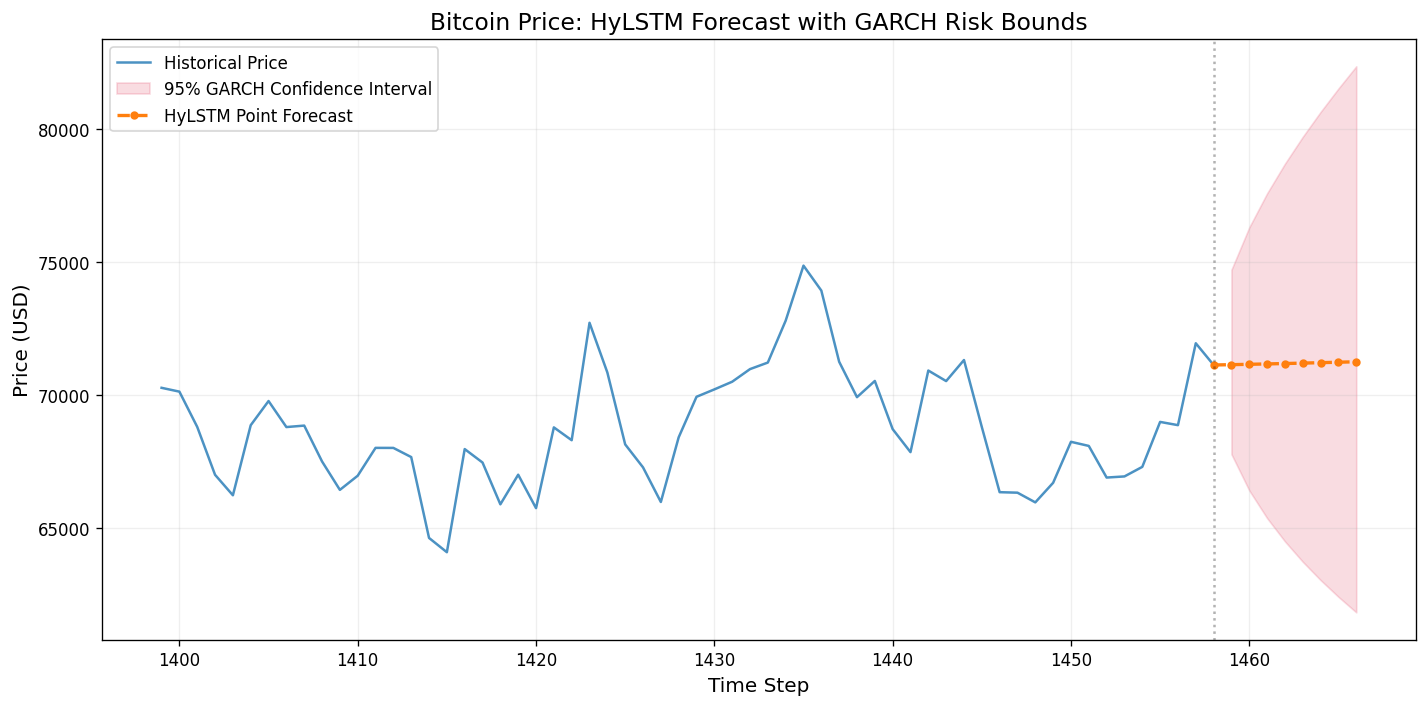

In [50]:
# --- 1. 索引对齐 ---
lookback = 60
history_series = BTC_data.iloc[-lookback:]
last_idx = history_series.index[-1]

# 预测步长索引 (8步)
forecast_steps = 8
forecast_index = np.arange(last_idx + 1, last_idx + forecast_steps + 1)

# 为了让线连起来，构造包含历史最后一项的路径
plot_idx_path = np.r_[last_idx, forecast_index]
plot_prices_path = np.r_[history_series['BTC_Close'].iloc[-1], hyb_prices]

# --- 2. 绘图 ---
plt.figure(figsize=(12, 6))

# A. 绘制历史观测值
plt.plot(history_series.index, history_series['BTC_Close'],
         label='Historical Price', color='#1f77b4', lw=1.5, alpha=0.8)

# B. 绘制 GARCH 置信区间 (阴影部分)
# 注意：lower_bounds 和 upper_bounds 对应的是 forecast_index 的位置
plt.fill_between(forecast_index, lower_bounds, upper_bounds,
                 color='crimson', alpha=0.15, label='95% GARCH Confidence Interval')

# C. 绘制 HyBiLSTM 最终预测路径 (橙色虚线)
plt.plot(plot_idx_path, plot_prices_path,
         label='HyLSTM Point Forecast', color='#ff7f0e',
         linestyle='--', marker='o', markersize=4, lw=2)

# D. 细节修饰
plt.axvline(x=last_idx, color='black', linestyle=':', alpha=0.3)  # 预测起点分割线
plt.title('Bitcoin Price: HyLSTM Forecast with GARCH Risk Bounds', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

# 动态调整 y 轴范围，确保阴影和历史数据都能看清
plt.tight_layout()
plt.show()

## LSTM can't find meaningful info from resid only

In [23]:
######################################################### using other DL method
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def preprocess_for_multistep(df, steps=5):
    data = df.copy()

    # 1. 定义需要转换为 Log Return 的特征列
    # 包含 BTC 本身以及所有的宏观、他币指标
    cols_to_transform = [
        'LTC_close', 'XRP_close', 'ETH_close', 'DOGE_close',
        'Gold_close', 'Silver_close', 'Oil_close', 'SP500_close',
        'NASDAQ_close', 'DXY_close', 'Treasury_10Y_close', 'EUR_close', 'JPY_close'
    ]

    # 2. 执行转换并重命名，同时计算 BTC 的 High/Low 波动率（可选但推荐）
    for col in cols_to_transform:
        if col in data.columns:
            # 计算对数收益率: ln(Price_t / Price_{t-1})
            data[f'{col}_ret'] = np.log(data[col] / data[col].shift(1))

    # 特殊处理：BTC 的高低价转为波动率 (Range)，比绝对值更有意义
    data['BTC_range'] = np.log(data['BTC_High'] / data['BTC_Low'])

    # 3. 构造 5 天的 Target (基于 BTC_Close 的未来收益)
    target_cols = []
    for f in range(1, steps + 1):
        col_name = f'target_f{f}'
        data[col_name] = np.log(data['BTC_Close'].shift(-f) / data['BTC_Close'])
        target_cols.append(col_name)

    # 4. 生成滞后特征 (Lagged Features)
    # 我们现在用 _ret (收益率) 和 _range 来做滞后，而不是原始价格
    lag_targets = [f'{c}_ret' for c in cols_to_transform if f'{c}_ret' in data.columns]
    lag_targets += ['Active_addr_cnt', 'BTC_range']

    for col in lag_targets:
        for i in range(1, 4):
            data[f'{col}_lag{i}'] = data[col].shift(i)
    # 5. 清理数据
    data = data.dropna()
    # 6. 划分 X 和 y
    # 移除所有包含 'close', 'High', 'Low', 'Open' 的原始绝对值列
    raw_price_cols = [c for c in data.columns if any(x in c for x in ['close', 'High', 'Low', 'Open'])
                      and '_ret' not in c and '_lag' not in c and 'target' not in c]
    real_time_cols = ['BTC_Close', 'DXY_close_ret', 'Active_addr_cnt',
                      'ETH_close_ret','LTC_close_ret', 'XRP_close_ret', 'DOGE_close_ret',
                      'Gold_close_ret', 'Silver_close_ret', 'Oil_close_ret', 'SP500_close_ret',
                      'Treasury_10Y_close_ret', 'EUR_close_ret', 'JPY_close_ret', 'NASDAQ_close_ret',
                      'BTC_Close_ret']
    # 显式排除
    drop_cols = raw_price_cols + ['Date', 'log_ret'] + target_cols + real_time_cols
    X = data.drop(columns=[c for c in drop_cols if c in data.columns])
    y = data[target_cols]
    return X, y

def create_sequences_multistep(X, y, time_steps=5):
    Xs, ys = [], []
    # y 现在已经是一个包含了 5 列的矩阵
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps].values) # 取出 5 个 target
    return np.array(Xs), np.array(ys)

def get_lstm_multistep_model(input_shape, output_steps=5):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(output_steps) #  5 days
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def train_and_evaluate_multistep(X, y):
    # 1. 增加正则化，降低树深度，防止背诵噪声
    models_ml = {
        "XGBoost": XGBRegressor(
            n_estimators=100,
            learning_rate=0.03, # 降低学习率
            max_depth=4,        # 限制深度，防止过拟合
            subsample=0.8,      # 随机采样特征
            reg_lambda=1.0      # L2 正则化
        ),
        "RandomForest": MultiOutputRegressor(RandomForestRegressor(
            n_estimators=100,
            max_depth=5,        # 显著降低深度（金融数据 5-6 层通常足够）
            min_samples_leaf=5, # 每个叶子节点最少样本，增加泛化力
            random_state=42
        )),
        "Ridge": MultiOutputRegressor(Ridge(alpha=10.0)) # 增大 alpha 抑制系数
    }

    # 2. 引入 gap=5，防止训练集末尾看到测试集开头的未来数据
    tscv = TimeSeriesSplit(n_splits=5, gap=5)

    results = {name: [] for name in list(models_ml.keys()) + ["LSTM"]}
    scaler = StandardScaler()

    for fold, (train_index, test_index) in enumerate(tscv.split(X)):
        X_train_raw, X_test_raw = X.iloc[train_index], X.iloc[test_index]
        y_train_raw, y_test_raw = y.iloc[train_index], y.iloc[test_index]

        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_test_scaled = scaler.transform(X_test_raw)

        # --- A. 传统机器学习训练 ---
        for name, model in models_ml.items():
            model.fit(X_train_scaled, y_train_raw)
            preds = model.predict(X_test_scaled)

            # 使用更健壮的 MAE 或 MAPE 评估
            mape = mean_absolute_percentage_error(y_test_raw + 1, preds + 1)
            results[name].append(mape)

        # --- B. LSTM 训练优化 ---
        time_steps = 5
        X_train_3d, y_train_3d = create_sequences_multistep(pd.DataFrame(X_train_scaled), y_train_raw, time_steps)
        X_test_3d, y_test_3d = create_sequences_multistep(pd.DataFrame(X_test_scaled), y_test_raw, time_steps)

        # 增加 EarlyStopping 防止 LSTM 在噪声上过度迭代
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,          # 5轮内loss不下降就停止
            restore_best_weights=True
        )

        lstm_model = get_lstm_multistep_model((X_train_3d.shape[1], X_train_3d.shape[2]), output_steps=5)

        # 传入 validation_data 用于监控过拟合
        lstm_model.fit(
            X_train_3d, y_train_3d,
            epochs=50,
            batch_size=32,
            validation_data=(X_test_3d, y_test_3d), # 监控验证集
            callbacks=[early_stop],
            verbose=0
        )

        lstm_preds = lstm_model.predict(X_test_3d)
        lstm_mape = mean_absolute_percentage_error(y_test_3d + 1, lstm_preds + 1)
        results["LSTM"].append(lstm_mape)
        print(f"Fold {fold} | LSTM MAPE: {lstm_mape:.6f} | RF MAPE: {results['RandomForest'][-1]:.6f}")

    return results


In [25]:
from sklearn.preprocessing import StandardScaler

DL_df= pd.read_excel("Macro_BTC_Dataset.xlsx","Sheet1")
X, y = preprocess_for_multistep(DL_df, steps=5)

# --- 检查全部特征列表 ---
all_features = X.columns.tolist()

print(f"\n{'='*20} 完整特征清单 (Total: {len(all_features)}) {'='*20}")
print("all_features:", all_features)

# 按类别分组显示，方便你核对
price_feats = [f for f in all_features if 'ret' in f.lower() or 'BTC' in f]
onchain_feats = [f for f in all_features if any(x in f for x in ['addr', 'Xfer', 'hash', 'Diff', 'size', 'fees'])]

print(f"1. 市场/价格特征 ({len(price_feats)}个): {price_feats}")
print(f"2. 链上数据特征 ({len(onchain_feats)}个): {onchain_feats}")

print(f"\n{'='*20} 数据矩阵横截面 (Raw Data Sample) {'='*20}")
# 打印前 5 行的全部特征（由于列很多，我们转置显示方便阅读）
print(X.head(1).T)

print(f"\n{'='*20} 预测目标横截面 (Target Sample) {'='*20}")
print(y.head(1).T)


==================== 完整特征清单 (Total: 59) ====================
all_features: ['BTC_Volume', 'Xfer_cnt', 'Mean_hash_rate', 'Difficulty', 'Total_fees_USD', 'Mean_block_size', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'BTC_range', 'LTC_close_ret_lag1', 'LTC_close_ret_lag2', 'LTC_close_ret_lag3', 'XRP_close_ret_lag1', 'XRP_close_ret_lag2', 'XRP_close_ret_lag3', 'ETH_close_ret_lag1', 'ETH_close_ret_lag2', 'ETH_close_ret_lag3', 'DOGE_close_ret_lag1', 'DOGE_close_ret_lag2', 'DOGE_close_ret_lag3', 'Gold_close_ret_lag1', 'Gold_close_ret_lag2', 'Gold_close_ret_lag3', 'Silver_close_ret_lag1', 'Silver_close_ret_lag2', 'Silver_close_ret_lag3', 'Oil_close_ret_lag1', 'Oil_close_ret_lag2', 'Oil_close_ret_lag3', 'SP500_close_ret_lag1', 'SP500_close_ret_lag2', 'SP500_close_ret_lag3', 'NASDAQ_close_ret_lag1', 'NASDAQ_close_ret_lag2', 'NASDAQ_close_ret_lag3', 'DXY_close_ret_lag1', 'DXY_close_ret_lag2', 'DXY_close_ret_lag3', 'Treasury_10Y_close_ret_lag1', 'Treasury_10Y_cl

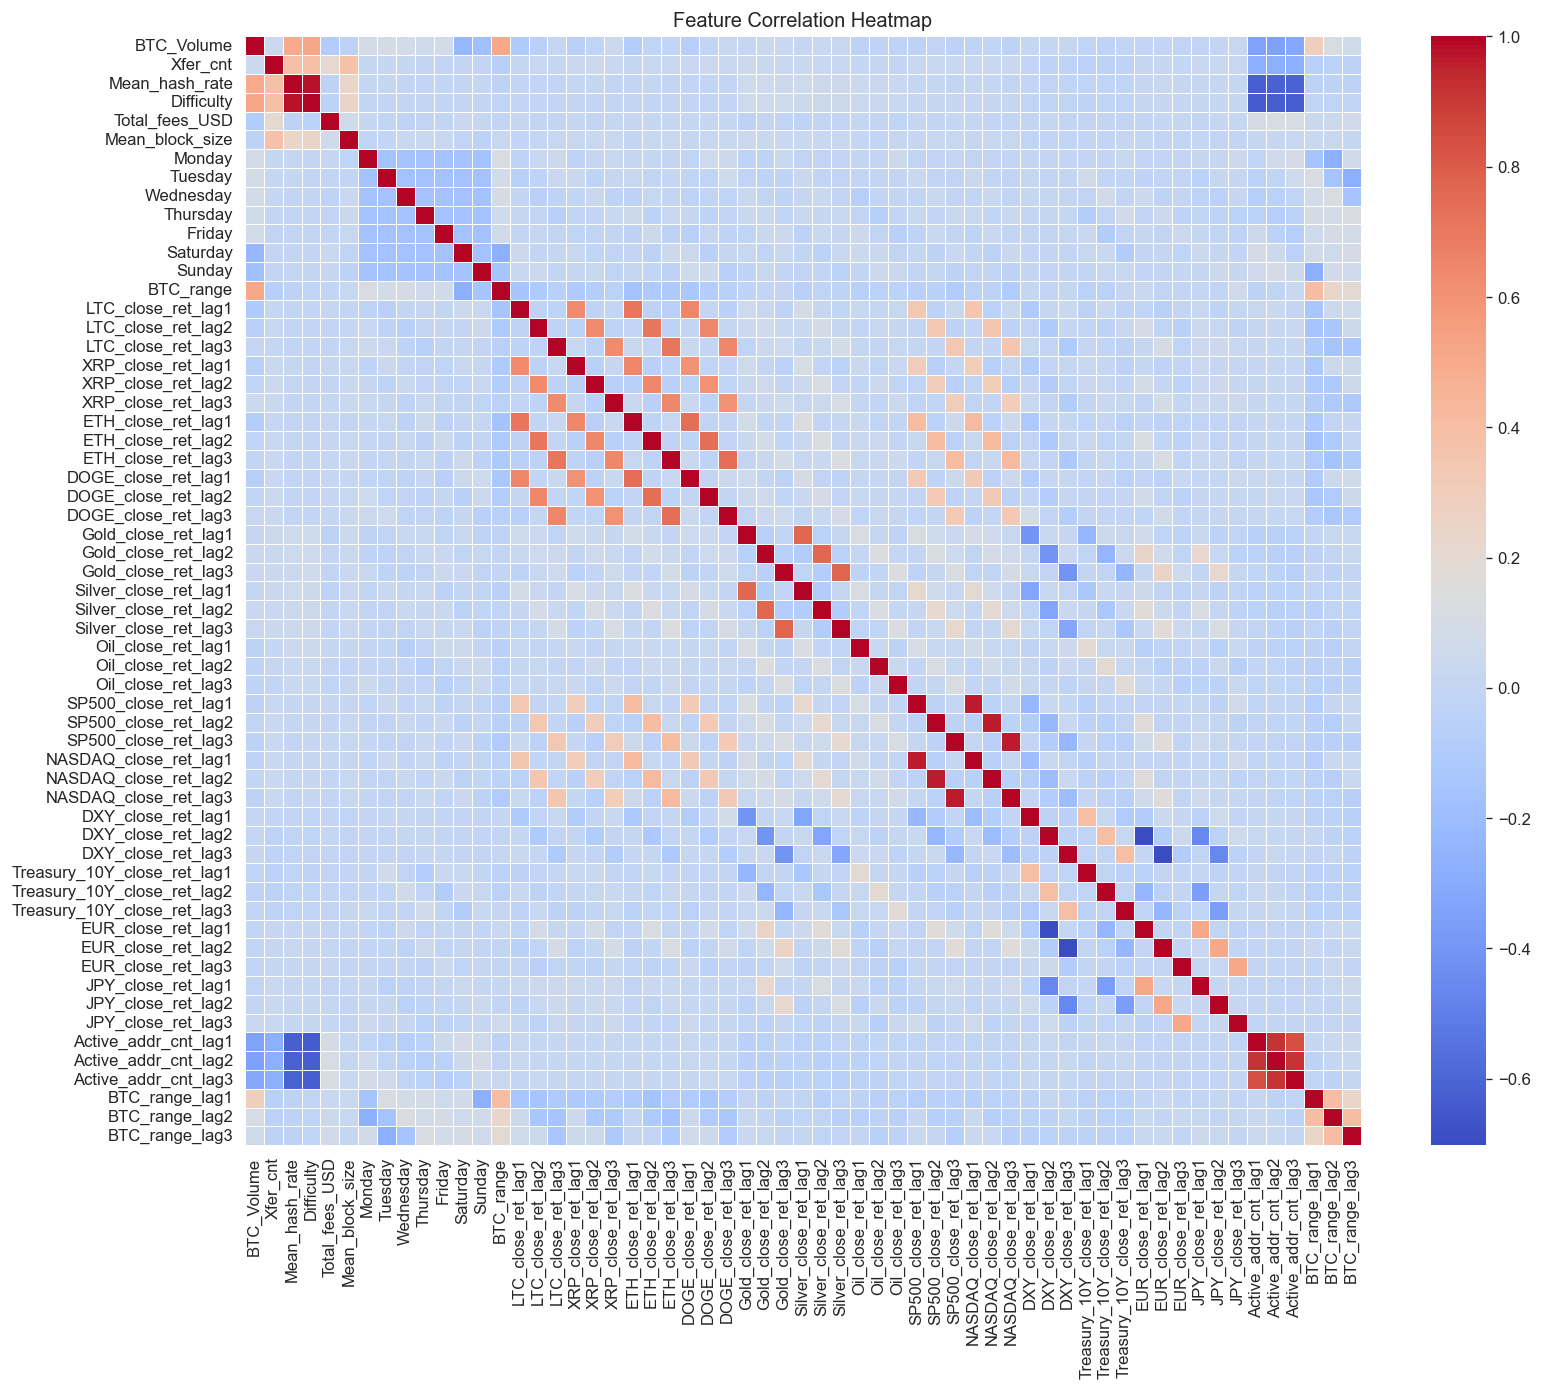

建议剔除或合并的高相关特征 (Corr > 0.9): ['Difficulty', 'NASDAQ_close_ret_lag1', 'NASDAQ_close_ret_lag2', 'NASDAQ_close_ret_lag3', 'Active_addr_cnt_lag2', 'Active_addr_cnt_lag3']


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation(X):
    # 计算相关系数
    corr = X.corr()
    # 绘图
    plt.figure(figsize=(15, 12))
    sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title("Feature Correlation Heatmap")
    plt.show()
    # 打印高度相关的特征对
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    high_corr = [column for column in upper.columns if any(upper[column] > 0.90)]
    print(f"建议剔除或合并的高相关特征 (Corr > 0.9): {high_corr}")
# 在预处理后调用
plot_correlation(X)

已清理冗余特征，剩余特征数: 54


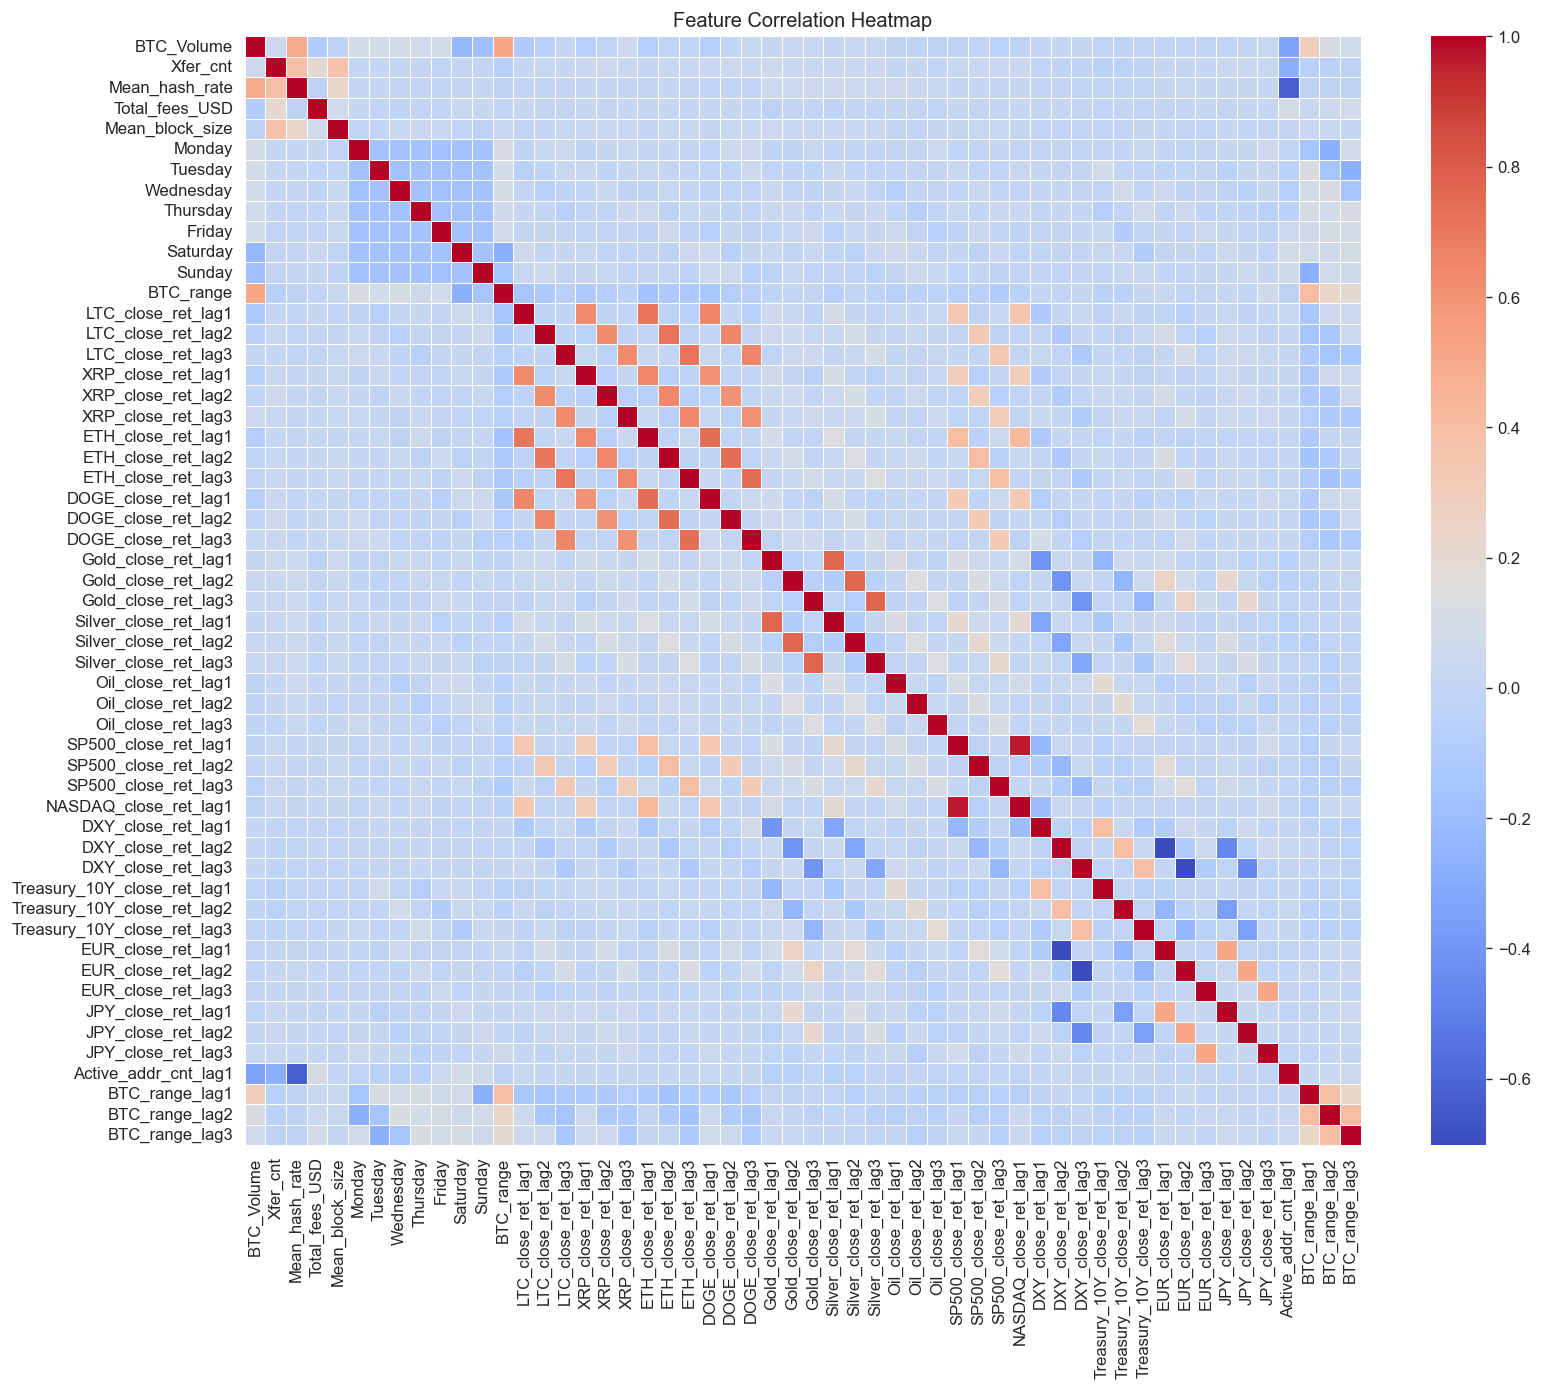

建议剔除或合并的高相关特征 (Corr > 0.9): ['NASDAQ_close_ret_lag1']


In [27]:
def refine_features(X):
    # 1. 针对 NASDAQ: 消除由于补全数据导致的严重共线性
    # 只保留 lag1，因为预测明天时，lag1 是最新的已知信息
    nasdaq_to_drop = [c for c in X.columns if 'NASDAQ_close_ret' in c and 'lag1' not in c]
    # 2. 针对 链上数据: 只保留最新的滞后项
    onchain_to_drop = ['Active_addr_cnt_lag2', 'Active_addr_cnt_lag3']
    # 3. 针对 难度: 绝对值对日收益率几乎无意义
    basic_to_drop = ['Difficulty']
    # 执行删除
    X_refined = X.drop(columns=nasdaq_to_drop + onchain_to_drop + basic_to_drop, errors='ignore')
    print(f"已清理冗余特征，剩余特征数: {X_refined.shape[1]}")
    return X_refined

X = refine_features(X)
plot_correlation(X)


检测到美股指数高度相关，优先保留 NASDAQ，移除 SP500...


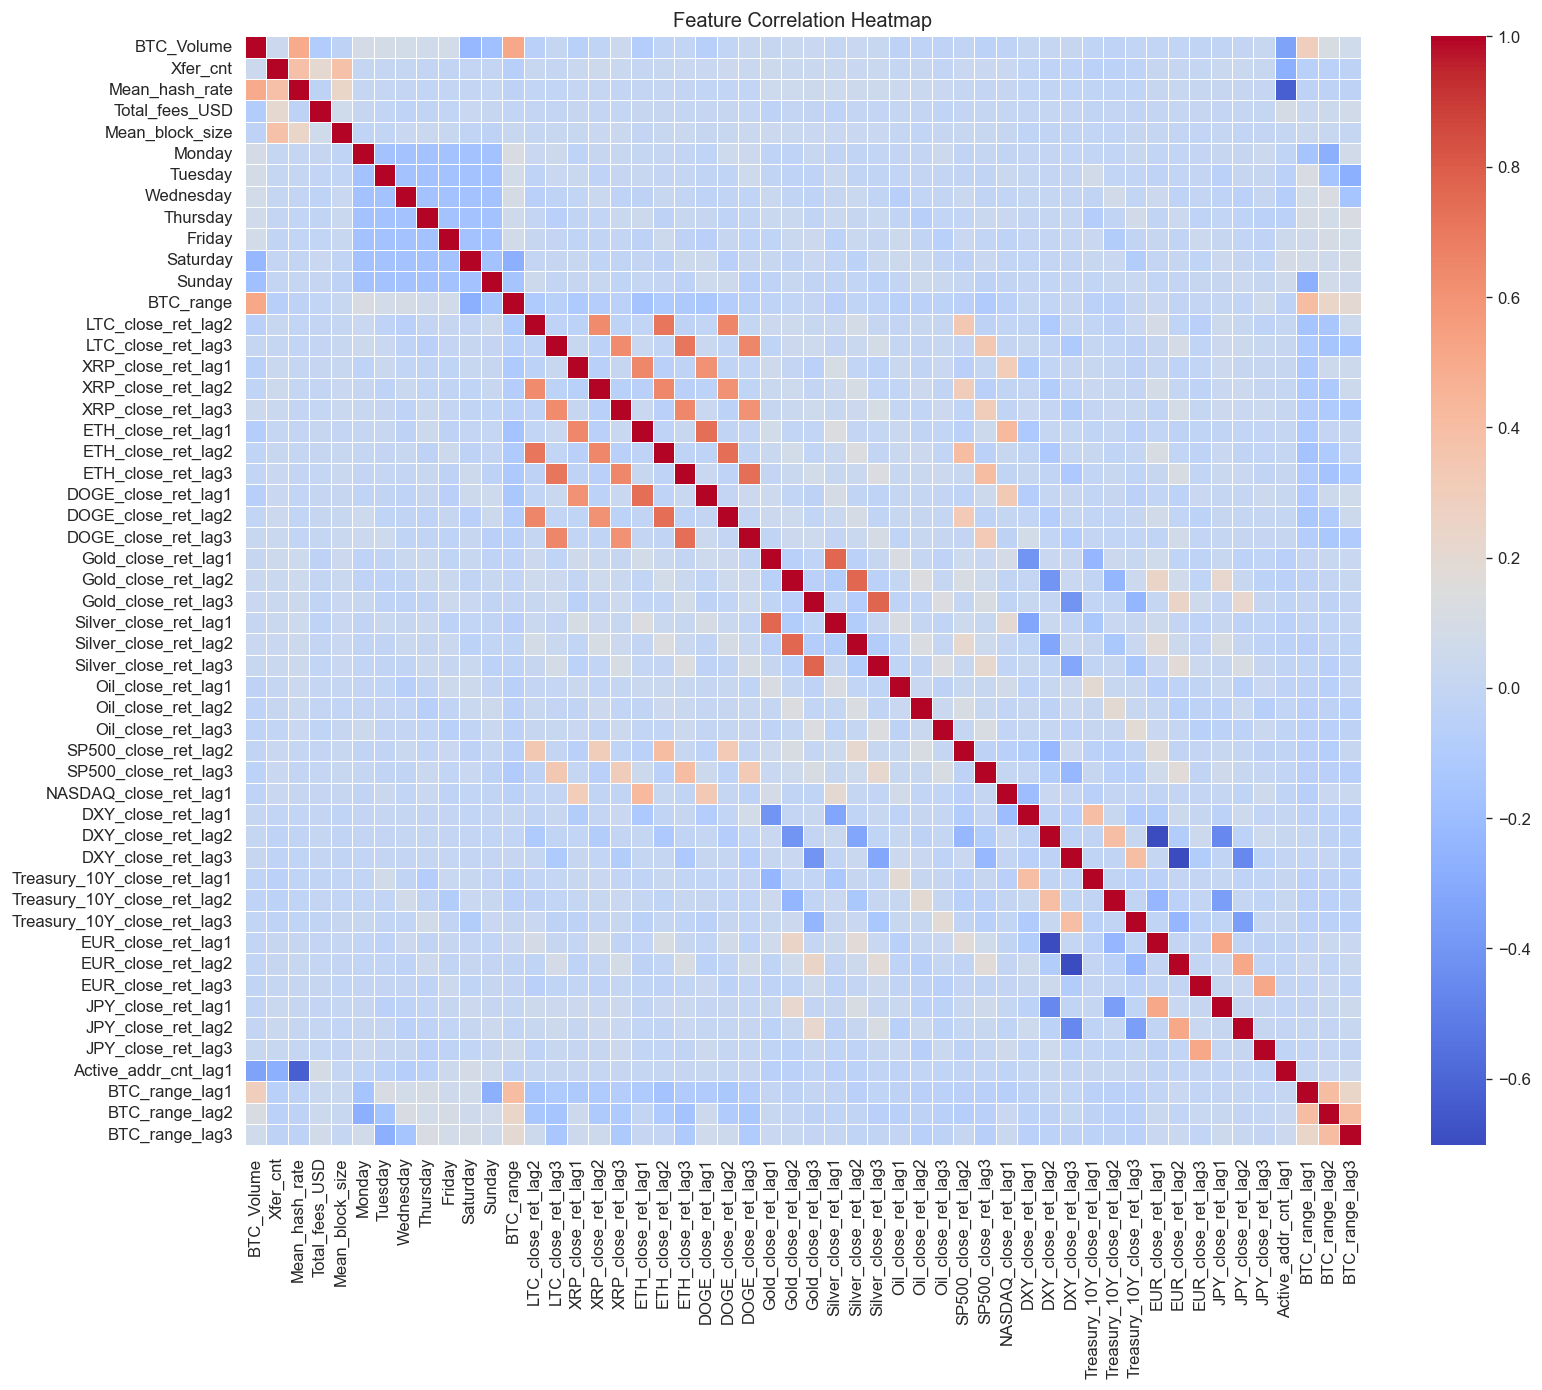

建议剔除或合并的高相关特征 (Corr > 0.9): []


In [28]:
def refine_features_v2(X):
    to_drop = []
    # 1. 处理 NASDAQ 和 SP500 的高度共线性
    if 'NASDAQ_close_ret_lag1' in X.columns and 'SP500_close_ret_lag1' in X.columns:
        print("检测到美股指数高度相关，优先保留 NASDAQ，移除 SP500...")
        to_drop.append('SP500_close_ret_lag1')
    # 2. 检查是否有其他的 lag1/lag2 依然过高
    if 'ETH_close_ret_lag1' in X.columns and 'LTC_close_ret_lag1' in X.columns:
        # 这里可以保留 ETH，因为它交易量更大，代表性更强
        to_drop.append('LTC_close_ret_lag1')
    X_refined = X.drop(columns=to_drop, errors='ignore')
    return X_refined

X = refine_features_v2(X)
plot_correlation(X)

In [29]:
train_and_evaluate_multistep(X, y)

C:\Users\wolff\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 0 | LSTM MAPE: 0.065561 | RF MAPE: 0.031337


C:\Users\wolff\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Fold 1 | LSTM MAPE: 0.034671 | RF MAPE: 0.031560


C:\Users\wolff\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

C:\Users\wolff\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 3 | LSTM MAPE: 0.035937 | RF MAPE: 0.028351


C:\Users\wolff\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Fold 4 | LSTM MAPE: 0.032506 | RF MAPE: 0.031668


{'XGBoost': [0.05867805331945419,
  0.03195904195308685,
  0.03726448863744736,
  0.030867820605635643,
  0.031715016812086105],
 'RandomForest': [0.031337471833482455,
  0.03155984732176042,
  0.034698224720185286,
  0.028351318343651642,
  0.03166818861152431],
 'Ridge': [0.0691846808753622,
  0.03356478346379978,
  0.04300824724439627,
  0.03512133526463233,
  0.032325350751143345],
 'LSTM': [0.06556094945313916,
  0.03467135180640109,
  0.03897123038842252,
  0.03593741752893408,
  0.03250604986873704]}

[71101.1955 71288.4641 71597.2849 70982.7815 71704.3766]


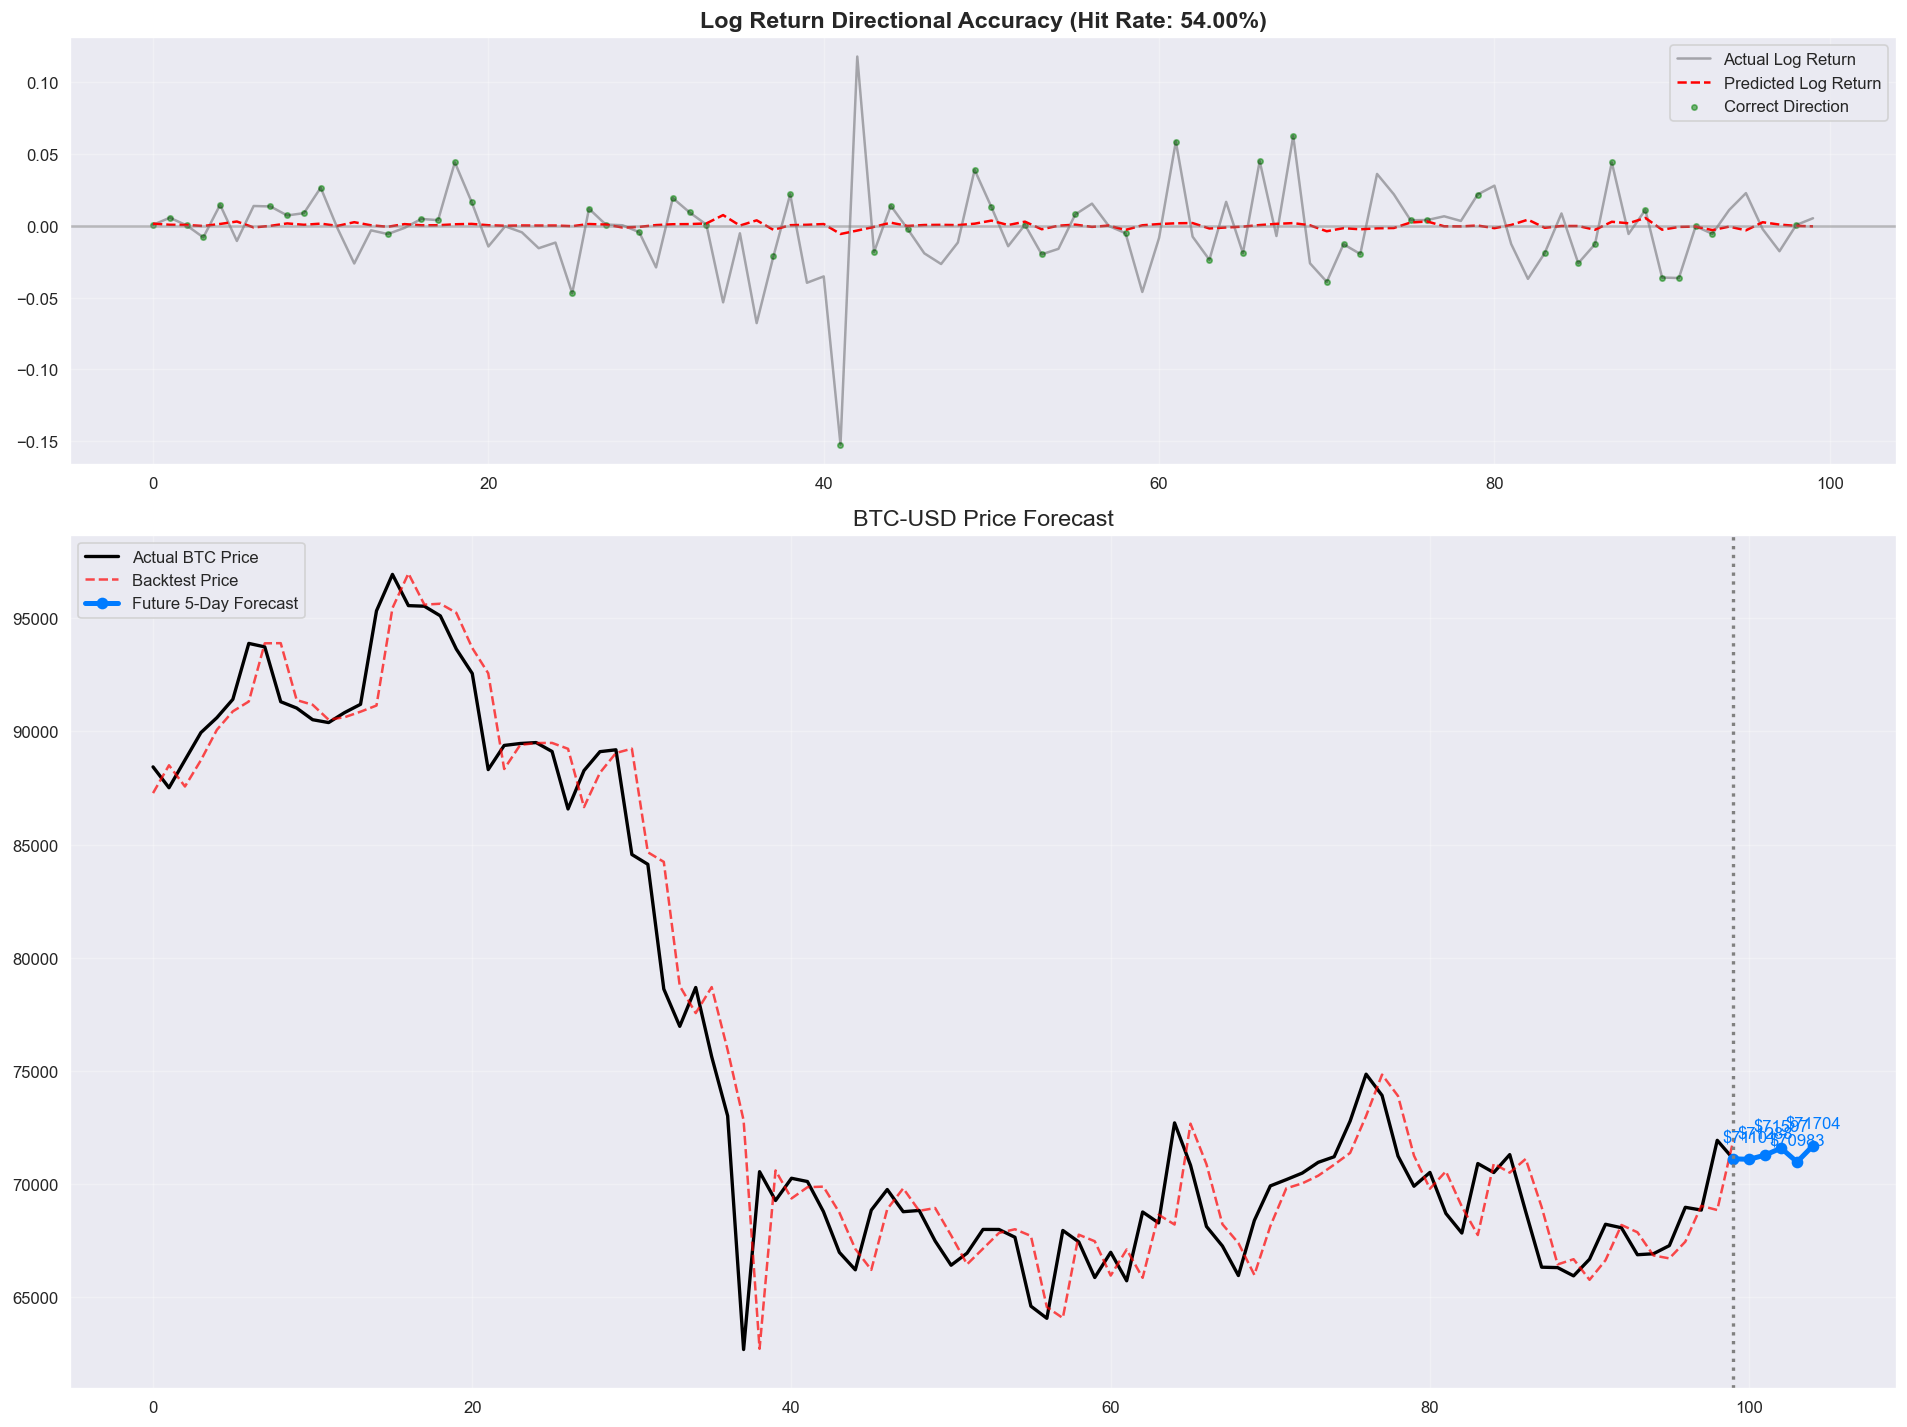

方向预测评估 (最近 100 天):
总测试天数: 100
方向预测正确天数: 54
方向命中率 (Hit Rate): 54.00%


In [31]:
import matplotlib.pyplot as plt

def finalize_and_visualize(X, y, df_original, test_size=100):
    # --- 1 & 2. 训练与预测逻辑 (保持不变) ---
    X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

    best_model = MultiOutputRegressor(RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1
    ))
    best_model.fit(X_train, y_train)

    backtest_preds_raw = best_model.predict(X_test)
    latest_feature = X.iloc[[-1]]
    future_preds_raw = best_model.predict(latest_feature)[0]

    # --- 新增：方向准确度 (Hit Rate) 计算 ---
    actual_returns = y.iloc[-test_size:]['target_f1'].values
    pred_returns = backtest_preds_raw[:, 0]

    # 计算符号是否一致 (1为同号, 0为异号)
    hits = (np.sign(actual_returns) == np.sign(pred_returns)).astype(int)
    hit_rate = np.mean(hits) * 100

    # --- 绘图逻辑 ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 2]})

    # --- 图 1: Log Return 与命中率标注 ---
    ax1.plot(range(test_size), actual_returns, color='black', alpha=0.3, label='Actual Log Return')
    ax1.plot(range(test_size), pred_returns, color='red', linestyle='--', label='Predicted Log Return')

    # 高亮预测正确的点 (用浅绿色背景或小点)
    correct_indices = np.where(hits == 1)[0]
    ax1.scatter(correct_indices, [actual_returns[i] for i in correct_indices],
                color='green', s=10, alpha=0.5, label='Correct Direction')

    ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    ax1.set_title(f"Log Return Directional Accuracy (Hit Rate: {hit_rate:.2f}%)", fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- 图 2: Price 与未来预测 (保持不变) ---
    actual_prices = df_original['BTC_Close'].iloc[-test_size:].values
    prev_actual_prices = df_original['BTC_Close'].iloc[-test_size-1:-1].values
    backtest_prices = prev_actual_prices * np.exp(pred_returns)
    current_price = actual_prices[-1]
    future_prices = current_price * np.exp(future_preds_raw)

    print(future_prices)

    ax2.plot(range(test_size), actual_prices, color='black', label='Actual BTC Price', linewidth=2)
    ax2.plot(range(test_size), backtest_prices, color='red', linestyle='--', alpha=0.7, label='Backtest Price')

    future_indices = range(test_size - 1, test_size + 5)
    future_plot_values = np.concatenate(([actual_prices[-1]], future_prices))
    ax2.plot(future_indices, future_plot_values, color='#007bff', linewidth=3, marker='o', label='Future 5-Day Forecast')

    ax2.axvline(x=test_size - 1, color='gray', linestyle=':', linewidth=2)
    for i, p in enumerate(future_prices):
        ax2.annotate(f"${p:.0f}", (test_size + i, p), textcoords="offset points", xytext=(0,10), ha='center', color='#007bff')

    ax2.set_title("BTC-USD Price Forecast", fontsize=14)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 输出评估报告
    print(f"方向预测评估 (最近 {test_size} 天):")
    print(f"总测试天数: {test_size}")
    print(f"方向预测正确天数: {np.sum(hits)}")
    print(f"方向命中率 (Hit Rate): {hit_rate:.2f}%")

    return best_model
# 调用示例
# 注意：df_original 必须包含原始的 BTC_Close 列
future_5d = finalize_and_visualize(X, y, DL_df)